In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_excel("cleaned_coverage-data.xlsx")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 399858
Columns: 11


In [ ]:
print(df.columns.tolist())

['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']


In [ ]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
GROUP                                 0
CODE                                  0
NAME                               1274
YEAR                                  0
ANTIGEN                               0
ANTIGEN_DESCRIPTION                   0
COVERAGE_CATEGORY                     0
COVERAGE_CATEGORY_DESCRIPTION         0
TARGET_NUMBER                    320828
DOSES                            320531
COVERAGE                         169381
dtype: int64


In [ ]:
df["NAME"] = df["NAME"].fillna("Unknown")

print("Missing NAME values:", df["NAME"].isnull().sum())

Missing NAME values: 0


In [ ]:
print("TARGET_NUMBER missing values:", df["TARGET_NUMBER"].isnull().sum())

TARGET_NUMBER missing values: 320828


In [ ]:
print("TARGET_NUMBER available values:", df["TARGET_NUMBER"].notnull().sum())



TARGET_NUMBER available values: 79030


In [ ]:
print("DOSES missing values:", df["DOSES"].isnull().sum())

DOSES missing values: 320531


In [ ]:
print("DOSES available values:", df["DOSES"].notnull().sum())

DOSES available values: 79327


In [ ]:
print("COVERAGE missing values:", df["COVERAGE"].isnull().sum())

COVERAGE missing values: 169381


In [ ]:
print("COVERAGE available values:", df["COVERAGE"].notnull().sum())

COVERAGE available values: 230477


In [ ]:
print(df["COVERAGE"].describe())

count    230477.000000
mean         78.032914
std          74.891697
min           0.000000
25%          69.320000
50%          88.790000
75%          96.000000
max       32000.000000
Name: COVERAGE, dtype: float64


In [ ]:
print("Coverage values greater than 100:", (df["COVERAGE"] > 100).sum())

Coverage values greater than 100: 5097


In [ ]:
print("Coverage values greater than 1000:", (df["COVERAGE"] > 1000).sum())

Coverage values greater than 1000: 6


In [ ]:
# ==========================================
# COVERAGE DATA - COMPLETE DATA QUALITY CHECK
# ==========================================

print("===== COVERAGE DATA QUALITY REPORT =====")

# 1. Missing values
print("\n1. Missing Values:")
print(df.isnull().sum())

# 2. Duplicate rows
print("\n2. Duplicate Rows:")
print(df.duplicated().sum())

# 3. Coverage statistics
print("\n3. Coverage Statistics:")
print(df["COVERAGE"].describe())

# 4. Coverage greater than 100
print("\n4. Coverage > 100:")
print((df["COVERAGE"] > 100).sum())

# 5. Coverage greater than 1000
print("\n5. Coverage > 1000:")
print((df["COVERAGE"] > 1000).sum())

# 6. Coverage between 0 and 100
print("\n6. Coverage between 0 and 100:")
print(((df["COVERAGE"] >= 0) & (df["COVERAGE"] <= 100)).sum())

# 7. Data types
print("\n7. Data Types:")
print(df.dtypes)

# 8. Dataset shape
print("\n8. Dataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n===== CHECK COMPLETED =====")

===== COVERAGE DATA QUALITY REPORT =====

1. Missing Values:
GROUP                                 0
CODE                                  0
NAME                                  0
YEAR                                  0
ANTIGEN                               0
ANTIGEN_DESCRIPTION                   0
COVERAGE_CATEGORY                     0
COVERAGE_CATEGORY_DESCRIPTION         0
TARGET_NUMBER                    320828
DOSES                            320531
COVERAGE                         169381
dtype: int64

2. Duplicate Rows:
0

3. Coverage Statistics:
count    230477.000000
mean         78.032914
std          74.891697
min           0.000000
25%          69.320000
50%          88.790000
75%          96.000000
max       32000.000000
Name: COVERAGE, dtype: float64

4. Coverage > 100:
5097

5. Coverage > 1000:
6

6. Coverage between 0 and 100:
225380

7. Data Types:
GROUP                             object
CODE                              object
NAME                              objec

In [ ]:
# Basic Coverage Analysis

print("Coverage by Year:")
print(df.groupby("YEAR")["COVERAGE"].mean().tail(10))

Coverage by Year:
YEAR
2014    80.461696
2015    80.513076
2016    81.274453
2017    81.216230
2018    83.907838
2019    80.521072
2020    80.479767
2021    77.907310
2022    79.094810
2023    80.039306
Name: COVERAGE, dtype: float64


    YEAR   COVERAGE
0   1980  44.250829
1   1981  46.115658
2   1982  48.783593
3   1983  52.860714
4   1984  53.969494
5   1985  56.211463
6   1986  60.273895
7   1987  63.739984
8   1988  67.413137
9   1989  70.747811
10  1990  74.989291
11  1991  74.413607
12  1992  74.327518
13  1993  75.116044
14  1994  76.338940
15  1995  78.236037
16  1996  78.876689
17  1997  78.664455
18  1998  78.240704
19  1999  78.835113
20  2000  78.365351
21  2001  77.265976
22  2002  79.538657
23  2003  81.070494
24  2004  81.973992
25  2005  83.239527
26  2006  83.877556
27  2007  83.736920
28  2008  83.830264
29  2009  84.472188
30  2010  79.340735
31  2011  79.811688
32  2012  80.107451
33  2013  79.648073
34  2014  80.461696
35  2015  80.513076
36  2016  81.274453
37  2017  81.216230
38  2018  83.907838
39  2019  80.521072
40  2020  80.479767
41  2021  77.907310
42  2022  79.094810
43  2023  80.039306


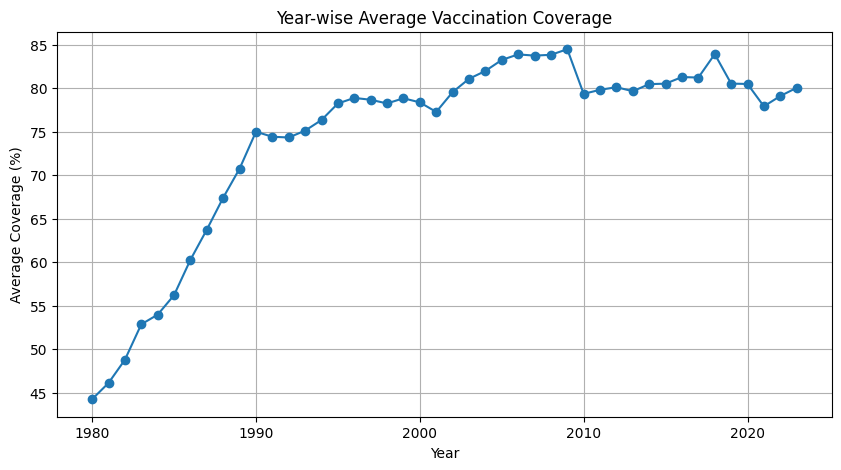

In [ ]:
# Year-wise Vaccination Coverage Trend

yearly_coverage = (
    df.groupby("YEAR")["COVERAGE"]
      .mean()
      .reset_index()
)

print(yearly_coverage)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    yearly_coverage["YEAR"],
    yearly_coverage["COVERAGE"],
    marker="o"
)

plt.title("Year-wise Average Vaccination Coverage")
plt.xlabel("Year")
plt.ylabel("Average Coverage (%)")
plt.grid(True)
plt.show()

In [ ]:
print("Highest Average Coverage:")
print(yearly_coverage.loc[yearly_coverage["COVERAGE"].idxmax()])

print("\nLowest Average Coverage:")
print(yearly_coverage.loc[yearly_coverage["COVERAGE"].idxmin()])

Highest Average Coverage:
YEAR        2009.000000
COVERAGE      84.472188
Name: 29, dtype: float64

Lowest Average Coverage:
YEAR        1980.000000
COVERAGE      44.250829
Name: 0, dtype: float64


In [ ]:
# ==========================================
# COVERAGE DATA - EDA SUMMARY
# ==========================================

print("========== COVERAGE EDA SUMMARY ==========")

# 1. Total records
print("\n1. Total Records:")
print(len(df))

# 2. Number of countries/regions
print("\n2. Unique Countries/Regions:")
print(df["NAME"].nunique())

# 3. Year range
print("\n3. Year Range:")
print("From:", df["YEAR"].min())
print("To:", df["YEAR"].max())

# 4. Unique antigens
print("\n4. Unique Antigens:")
print(df["ANTIGEN"].nunique())

# 5. Average coverage
print("\n5. Overall Average Coverage:")
print(round(df["COVERAGE"].mean(), 2), "%")

# 6. Highest average coverage year
highest = yearly_coverage.loc[yearly_coverage["COVERAGE"].idxmax()]
print("\n6. Highest Average Coverage:")
print("Year:", int(highest["YEAR"]))
print("Coverage:", round(highest["COVERAGE"], 2), "%")

# 7. Lowest average coverage year
lowest = yearly_coverage.loc[yearly_coverage["COVERAGE"].idxmin()]
print("\n7. Lowest Average Coverage:")
print("Year:", int(lowest["YEAR"]))
print("Coverage:", round(lowest["COVERAGE"], 2), "%")

# 8. Coverage between 0 and 100
valid_coverage = df[
    (df["COVERAGE"] >= 0) &
    (df["COVERAGE"] <= 100)
]

print("\n8. Valid Coverage Records (0-100):")
print(len(valid_coverage))

# 9. Coverage greater than 100
print("\n9. Coverage > 100:")
print((df["COVERAGE"] > 100).sum())

# 10. Duplicate records
print("\n10. Duplicate Records:")
print(df.duplicated().sum())

print("\n========== EDA COMPLETED ==========")

========== COVERAGE EDA SUMMARY ==========

1. Total Records:
399858

2. Unique Countries/Regions:
243

3. Year Range:
From: 1980
To: 2023

4. Unique Antigens:
69

5. Overall Average Coverage:
78.03 %

6. Highest Average Coverage:
Year: 2009
Coverage: 84.47 %

7. Lowest Average Coverage:
Year: 1980
Coverage: 44.25 %

8. Valid Coverage Records (0-100):
225380

9. Coverage > 100:
5097

10. Duplicate Records:
0

========== EDA COMPLETED ==========


In [ ]:
# Load Incidence Rate Dataset

incidence_df = pd.read_excel("cleaned_incidence-rate-data.xlsx")

print("Incidence Rate Dataset loaded successfully!")
print("Rows:", incidence_df.shape[0])
print("Columns:", incidence_df.shape[1])

Incidence Rate Dataset loaded successfully!
Rows: 84945
Columns: 8


In [ ]:
# ==========================================
# INCIDENCE RATE - DATA QUALITY CHECK
# ==========================================

print("===== INCIDENCE RATE DATA QUALITY REPORT =====")

print("\n1. Columns:")
print(incidence_df.columns.tolist())

print("\n2. Missing Values:")
print(incidence_df.isnull().sum())

print("\n3. Duplicate Rows:")
print(incidence_df.duplicated().sum())

print("\n4. Dataset Shape:")
print("Rows:", incidence_df.shape[0])
print("Columns:", incidence_df.shape[1])

print("\n===== CHECK COMPLETED =====")

===== INCIDENCE RATE DATA QUALITY REPORT =====

1. Columns:
['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']

2. Missing Values:
GROUP                      0
CODE                       0
NAME                       0
YEAR                       0
DISEASE                    0
DISEASE_DESCRIPTION        0
DENOMINATOR                0
INCIDENCE_RATE         23361
dtype: int64

3. Duplicate Rows:
0

4. Dataset Shape:
Rows: 84945
Columns: 8

===== CHECK COMPLETED =====


In [ ]:
print("===== INCIDENCE RATE STATISTICS =====")

print("\nBasic Statistics:")
print(incidence_df["INCIDENCE_RATE"].describe())

print("\nData Types:")
print(incidence_df.dtypes)

print("\nYear Range:")
print("From:", incidence_df["YEAR"].min())
print("To:", incidence_df["YEAR"].max())

print("\nUnique Diseases:")
print(incidence_df["DISEASE"].nunique())

print("\nUnique Countries/Regions:")
print(incidence_df["NAME"].nunique())

print("\n===== STATISTICS COMPLETED =====")

===== INCIDENCE RATE STATISTICS =====

Basic Statistics:
count    61584.000000
mean       109.448781
std        992.276983
min          0.000000
25%          0.000000
50%          0.000000
75%          4.600000
max      69101.300000
Name: INCIDENCE_RATE, dtype: float64

Data Types:
GROUP                   object
CODE                    object
NAME                    object
YEAR                     int64
DISEASE                 object
DISEASE_DESCRIPTION     object
DENOMINATOR             object
INCIDENCE_RATE         float64
dtype: object

Year Range:
From: 1980
To: 2023

Unique Diseases:
13

Unique Countries/Regions:
221

===== STATISTICS COMPLETED =====


In [ ]:
print("===== INCIDENCE RATE DISTRIBUTION CHECK =====")

print("Missing values:",
      incidence_df["INCIDENCE_RATE"].isnull().sum())

print("Zero values:",
      (incidence_df["INCIDENCE_RATE"] == 0).sum())

print("Values greater than 0:",
      (incidence_df["INCIDENCE_RATE"] > 0).sum())

print("Values greater than 100:",
      (incidence_df["INCIDENCE_RATE"] > 100).sum())

print("Values greater than 1000:",
      (incidence_df["INCIDENCE_RATE"] > 1000).sum())

print("Maximum incidence rate:",
      incidence_df["INCIDENCE_RATE"].max())

===== INCIDENCE RATE DISTRIBUTION CHECK =====
Missing values: 23361
Zero values: 32642
Values greater than 0: 28942
Values greater than 100: 5200
Values greater than 1000: 1300
Maximum incidence rate: 69101.3


In [ ]:
print("===== INCIDENCE RATE EXTREME VALUES ANALYSIS =====")

# 1. Highest incidence rate records
print("\n--- Top 20 Highest Incidence Rates ---")

top_incidence = incidence_df[
    ["GROUP", "CODE", "NAME", "YEAR", "DISEASE", "INCIDENCE_RATE"]
].sort_values(
    by="INCIDENCE_RATE",
    ascending=False
).head(20)

display(top_incidence)


# 2. Incidence rate greater than 1000
print("\n--- Records with Incidence Rate > 1000 ---")

high_incidence = incidence_df[
    incidence_df["INCIDENCE_RATE"] > 1000
][
    ["GROUP", "CODE", "NAME", "YEAR", "DISEASE", "INCIDENCE_RATE"]
].sort_values(
    by="INCIDENCE_RATE",
    ascending=False
)

display(high_incidence.head(20))


# 3. Disease-wise average incidence rate
print("\n--- Disease-wise Average Incidence Rate ---")

disease_incidence = (
    incidence_df
    .groupby("DISEASE")["INCIDENCE_RATE"]
    .mean()
    .sort_values(ascending=False)
)

display(disease_incidence)


# 4. Year-wise average incidence rate
print("\n--- Year-wise Average Incidence Rate ---")

year_incidence = (
    incidence_df
    .groupby("YEAR")["INCIDENCE_RATE"]
    .mean()
    .reset_index()
)

display(year_incidence)


# 5. Basic summary
print("\n===== SUMMARY =====")

print("Highest incidence rate:",
      incidence_df["INCIDENCE_RATE"].max())

print("Lowest incidence rate:",
      incidence_df["INCIDENCE_RATE"].min())

print("Average incidence rate:",
      incidence_df["INCIDENCE_RATE"].mean())

print("Median incidence rate:",
      incidence_df["INCIDENCE_RATE"].median())

print("Number of diseases:",
      incidence_df["DISEASE"].nunique())

print("Number of countries/regions:",
      incidence_df["NAME"].nunique())

print("Year range:",
      incidence_df["YEAR"].min(),
      "to",
      incidence_df["YEAR"].max())

===== INCIDENCE RATE EXTREME VALUES ANALYSIS =====

--- Top 20 Highest Incidence Rates ---


,GROUP,CODE,NAME,YEAR,DISEASE,INCIDENCE_RATE
77891,COUNTRIES,TUV,Tuvalu,1980,MEASLES,69101.3
41112,COUNTRIES,KIR,Kiribati,1992,MEASLES,56116.5
56510,COUNTRIES,NIU,Niue,1991,MEASLES,49347.5
12213,COUNTRIES,BTN,Bhutan,1999,MUMPS,43863.6
67470,COUNTRIES,SLB,Solomon Islands,1989,MEASLES,42887.6
1906,COUNTRIES,ALB,Albania,1989,MEASLES,41723.4
16738,COUNTRIES,COK,Cook Islands,1989,MEASLES,40810.3
58997,COUNTRIES,OMN,Oman,1981,MEASLES,38473.7
4443,COUNTRIES,ATG,Antigua and Barbuda,1980,MEASLES,35512.2
77842,COUNTRIES,TUV,Tuvalu,1987,MEASLES,33926.7



--- Records with Incidence Rate > 1000 ---


,GROUP,CODE,NAME,YEAR,DISEASE,INCIDENCE_RATE
77891,COUNTRIES,TUV,Tuvalu,1980,MEASLES,69101.3
41112,COUNTRIES,KIR,Kiribati,1992,MEASLES,56116.5
56510,COUNTRIES,NIU,Niue,1991,MEASLES,49347.5
12213,COUNTRIES,BTN,Bhutan,1999,MUMPS,43863.6
67470,COUNTRIES,SLB,Solomon Islands,1989,MEASLES,42887.6
1906,COUNTRIES,ALB,Albania,1989,MEASLES,41723.4
16738,COUNTRIES,COK,Cook Islands,1989,MEASLES,40810.3
58997,COUNTRIES,OMN,Oman,1981,MEASLES,38473.7
4443,COUNTRIES,ATG,Antigua and Barbuda,1980,MEASLES,35512.2
77842,COUNTRIES,TUV,Tuvalu,1987,MEASLES,33926.7



--- Disease-wise Average Incidence Rate ---


,INCIDENCE_RATE
DISEASE,
MEASLES,535.640943
TYPHOID,348.502894
MUMPS,168.046005
PERTUSSIS,130.545548
RUBELLA,54.347889
TTETANUS,9.888190
INVASIVE_MENING,8.859831
DIPHTHERIA,4.259208
POLIO,0.874932



--- Year-wise Average Incidence Rate ---


,YEAR,INCIDENCE_RATE
0,1980,836.043665
1,1981,633.873150
2,1982,588.087779
3,1983,487.962529
4,1984,435.618837
5,1985,479.368634
6,1986,272.416763
7,1987,277.406455
8,1988,204.040492
9,1989,342.138539



===== SUMMARY =====
Highest incidence rate: 69101.3
Lowest incidence rate: 0.0
Average incidence rate: 109.44878052740974
Median incidence rate: 0.0
Number of diseases: 13
Number of countries/regions: 221
Year range: 1980 to 2023


In [ ]:
# ==========================================
# INCIDENCE RATE - MISSING & EXTREME ANALYSIS
# ==========================================

print("===== MISSING VALUE ANALYSIS =====")

# Disease-wise missing values
missing_by_disease = (
    incidence_df[incidence_df["INCIDENCE_RATE"].isnull()]
    .groupby("DISEASE")
    .size()
    .sort_values(ascending=False)
)

print("\nMissing INCIDENCE_RATE by Disease:")
display(missing_by_disease)


# Year-wise missing values
missing_by_year = (
    incidence_df[incidence_df["INCIDENCE_RATE"].isnull()]
    .groupby("YEAR")
    .size()
    .reset_index(name="Missing_Count")
)

print("\nMissing INCIDENCE_RATE by Year:")
display(missing_by_year.head(20))


# ==========================================
# EXTREME VALUE ANALYSIS
# ==========================================

print("\n===== EXTREME VALUE ANALYSIS =====")

# Count by disease for values > 100
greater_100 = (
    incidence_df[incidence_df["INCIDENCE_RATE"] > 100]
    .groupby("DISEASE")
    .size()
    .sort_values(ascending=False)
)

print("\nValues > 100 by Disease:")
display(greater_100)


# Count by disease for values > 1000
greater_1000 = (
    incidence_df[incidence_df["INCIDENCE_RATE"] > 1000]
    .groupby("DISEASE")
    .size()
    .sort_values(ascending=False)
)

print("\nValues > 1000 by Disease:")
display(greater_1000)


# ==========================================
# ZERO VALUE ANALYSIS
# ==========================================

print("\n===== ZERO VALUE ANALYSIS =====")

zero_by_disease = (
    incidence_df[incidence_df["INCIDENCE_RATE"] == 0]
    .groupby("DISEASE")
    .size()
    .sort_values(ascending=False)
)

print("\nZero Incidence Rate by Disease:")
display(zero_by_disease)


# ==========================================
# VALID DATA RANGE
# ==========================================

print("\n===== FINAL INCIDENCE DATA SUMMARY =====")

print("Total records:", len(incidence_df))

print("Missing incidence:",
      incidence_df["INCIDENCE_RATE"].isnull().sum())

print("Zero incidence:",
      (incidence_df["INCIDENCE_RATE"] == 0).sum())

print("Positive incidence:",
      (incidence_df["INCIDENCE_RATE"] > 0).sum())

print("Above 100:",
      (incidence_df["INCIDENCE_RATE"] > 100).sum())

print("Above 1000:",
      (incidence_df["INCIDENCE_RATE"] > 1000).sum())

print("Maximum incidence:",
      incidence_df["INCIDENCE_RATE"].max())

print("Minimum incidence:",
      incidence_df["INCIDENCE_RATE"].min())

print("Mean incidence:",
      incidence_df["INCIDENCE_RATE"].mean())

print("Median incidence:",
      incidence_df["INCIDENCE_RATE"].median())

===== MISSING VALUE ANALYSIS =====

Missing INCIDENCE_RATE by Disease:


,0
DISEASE,
YFEVER,5062
POLIO,4750
CRS,1854
MUMPS,1757
JAPENC,1579
NTETANUS,1558
TTETANUS,1532
DIPHTHERIA,1476
PERTUSSIS,1455



Missing INCIDENCE_RATE by Year:


,YEAR,Missing_Count
0,1980,671
1,1981,646
2,1982,633
3,1983,630
4,1984,624
5,1985,620
6,1986,619
7,1987,601
8,1988,590
9,1989,594



===== EXTREME VALUE ANALYSIS =====

Values > 100 by Disease:


...


Values > 1000 by Disease:


,0
DISEASE,
MEASLES,911
PERTUSSIS,199
MUMPS,101
RUBELLA,43
TYPHOID,38
TTETANUS,4
DIPHTHERIA,2
INVASIVE_MENING,1
POLIO,1



===== ZERO VALUE ANALYSIS =====

Zero Incidence Rate by Disease:


,0
DISEASE,
NTETANUS,5899
DIPHTHERIA,5175
POLIO,3906
YFEVER,3462
CRS,2991
TTETANUS,2423
MEASLES,2060
PERTUSSIS,2052
RUBELLA,1719



===== FINAL INCIDENCE DATA SUMMARY =====
Total records: 84945
Missing incidence: 23361
Zero incidence: 32642
Positive incidence: 28942
Above 100: 5200
Above 1000: 1300
Maximum incidence: 69101.3
Minimum incidence: 0.0
Mean incidence: 109.44878052740974
Median incidence: 0.0


In [ ]:
# ==========================================
# INCIDENCE RATE - MISSING VALUE HANDLING
# ==========================================

print("===== BEFORE CLEANING =====")

print("Total records:",
      len(incidence_df))

print("Missing INCIDENCE_RATE:",
      incidence_df["INCIDENCE_RATE"].isnull().sum())

print("Zero INCIDENCE_RATE:",
      (incidence_df["INCIDENCE_RATE"] == 0).sum())


# ------------------------------------------
# Create a separate dataframe for analysis
# ------------------------------------------

incidence_clean = incidence_df.dropna(
    subset=["INCIDENCE_RATE"]
).copy()


# ------------------------------------------
# Check after removing missing values
# ------------------------------------------

print("\n===== AFTER REMOVING MISSING VALUES =====")

print("Total records:",
      len(incidence_clean))

print("Missing INCIDENCE_RATE:",
      incidence_clean["INCIDENCE_RATE"].isnull().sum())

print("Zero INCIDENCE_RATE:",
      (incidence_clean["INCIDENCE_RATE"] == 0).sum())

print("Positive INCIDENCE_RATE:",
      (incidence_clean["INCIDENCE_RATE"] > 0).sum())


# ------------------------------------------
# Check duplicates
# ------------------------------------------

print("\n===== DUPLICATE CHECK =====")

print("Duplicate rows:",
      incidence_clean.duplicated().sum())


# ------------------------------------------
# Final statistics
# ------------------------------------------

print("\n===== CLEAN INCIDENCE SUMMARY =====")

print("Minimum:",
      incidence_clean["INCIDENCE_RATE"].min())

print("Maximum:",
      incidence_clean["INCIDENCE_RATE"].max())

print("Mean:",
      incidence_clean["INCIDENCE_RATE"].mean())

print("Median:",
      incidence_clean["INCIDENCE_RATE"].median())

print("Number of diseases:",
      incidence_clean["DISEASE"].nunique())

print("Number of countries/regions:",
      incidence_clean["NAME"].nunique())

print("Year range:",
      incidence_clean["YEAR"].min(),
      "to",
      incidence_clean["YEAR"].max())

===== BEFORE CLEANING =====
Total records: 84945
Missing INCIDENCE_RATE: 23361
Zero INCIDENCE_RATE: 32642

===== AFTER REMOVING MISSING VALUES =====
Total records: 61584
Missing INCIDENCE_RATE: 0
Zero INCIDENCE_RATE: 32642
Positive INCIDENCE_RATE: 28942

===== DUPLICATE CHECK =====
Duplicate rows: 0

===== CLEAN INCIDENCE SUMMARY =====
Minimum: 0.0
Maximum: 69101.3
Mean: 109.44878052740972
Median: 0.0
Number of diseases: 13
Number of countries/regions: 221
Year range: 1980 to 2023


In [ ]:
# ==========================================
# YEAR-WISE INCIDENCE RATE TREND
# ==========================================

year_incidence_clean = (
    incidence_clean
    .groupby("YEAR")["INCIDENCE_RATE"]
    .mean()
    .reset_index()
)

print("===== YEAR-WISE INCIDENCE RATE =====")

display(year_incidence_clean)


# Find highest and lowest average year
highest_year = year_incidence_clean.loc[
    year_incidence_clean["INCIDENCE_RATE"].idxmax()
]

lowest_year = year_incidence_clean.loc[
    year_incidence_clean["INCIDENCE_RATE"].idxmin()
]

print("\n===== TREND SUMMARY =====")

print(
    "Highest average incidence year:",
    int(highest_year["YEAR"]),
    "Rate:",
    round(highest_year["INCIDENCE_RATE"], 2)
)

print(
    "Lowest average incidence year:",
    int(lowest_year["YEAR"]),
    "Rate:",
    round(lowest_year["INCIDENCE_RATE"], 2)
)

===== YEAR-WISE INCIDENCE RATE =====


,YEAR,INCIDENCE_RATE
0,1980,836.043665
1,1981,633.873150
2,1982,588.087779
3,1983,487.962529
4,1984,435.618837
5,1985,479.368634
6,1986,272.416763
7,1987,277.406455
8,1988,204.040492
9,1989,342.138539



===== TREND SUMMARY =====
Highest average incidence year: 1980 Rate: 836.04
Lowest average incidence year: 2014 Rate: 14.26


In [ ]:
# ==========================================
# YEAR-WISE INCIDENCE RATE TREND
# ==========================================

year_incidence_clean = (
    incidence_clean
    .groupby("YEAR")["INCIDENCE_RATE"]
    .mean()
    .reset_index()
)

print("===== YEAR-WISE INCIDENCE RATE =====")

display(year_incidence_clean)


# Find highest and lowest average year
highest_year = year_incidence_clean.loc[
    year_incidence_clean["INCIDENCE_RATE"].idxmax()
]

lowest_year = year_incidence_clean.loc[
    year_incidence_clean["INCIDENCE_RATE"].idxmin()
]

print("\n===== TREND SUMMARY =====")

print(
    "Highest average incidence year:",
    int(highest_year["YEAR"]),
    "Rate:",
    round(highest_year["INCIDENCE_RATE"], 2)
)

print(
    "Lowest average incidence year:",
    int(lowest_year["YEAR"]),
    "Rate:",
    round(lowest_year["INCIDENCE_RATE"], 2)
)

===== YEAR-WISE INCIDENCE RATE =====


,YEAR,INCIDENCE_RATE
0,1980,836.043665
1,1981,633.873150
2,1982,588.087779
3,1983,487.962529
4,1984,435.618837
5,1985,479.368634
6,1986,272.416763
7,1987,277.406455
8,1988,204.040492
9,1989,342.138539



===== TREND SUMMARY =====
Highest average incidence year: 1980 Rate: 836.04
Lowest average incidence year: 2014 Rate: 14.26


In [ ]:
# ==========================================
# DISEASE-WISE INCIDENCE RATE ANALYSIS
# ==========================================

disease_incidence_clean = (
    incidence_clean
    .groupby("DISEASE")["INCIDENCE_RATE"]
    .agg(
        Average_Incidence="mean",
        Median_Incidence="median",
        Minimum_Incidence="min",
        Maximum_Incidence="max",
        Record_Count="count"
    )
    .reset_index()
    .sort_values(
        by="Average_Incidence",
        ascending=False
    )
)

print("===== DISEASE-WISE INCIDENCE ANALYSIS =====")

display(disease_incidence_clean)


# ------------------------------------------
# Highest and Lowest Average Incidence
# ------------------------------------------

highest_disease = disease_incidence_clean.iloc[0]

lowest_disease = disease_incidence_clean.iloc[-1]

print("\n===== DISEASE SUMMARY =====")

print(
    "Highest average incidence disease:",
    highest_disease["DISEASE"],
    "| Average:",
    round(highest_disease["Average_Incidence"], 2)
)

print(
    "Lowest average incidence disease:",
    lowest_disease["DISEASE"],
    "| Average:",
    round(lowest_disease["Average_Incidence"], 2)
)

===== DISEASE-WISE INCIDENCE ANALYSIS =====


,DISEASE,Average_Incidence,Median_Incidence,Minimum_Incidence,Maximum_Incidence,Record_Count
4,MEASLES,535.640943,16.5,0.0,69101.3,8419
11,TYPHOID,348.502894,0.1,0.0,22885.7,864
5,MUMPS,168.046005,9.0,0.0,43863.6,3367
7,PERTUSSIS,130.545548,7.3,0.0,17252.1,7726
9,RUBELLA,54.347889,0.5,0.0,22383.1,4310
10,TTETANUS,9.888190,0.6,0.0,1322.7,7595
2,INVASIVE_MENING,8.859831,0.4,0.0,2953.6,590
1,DIPHTHERIA,4.259208,0.0,0.0,6832.4,7705
8,POLIO,0.874932,0.0,0.0,1927.8,4380
12,YFEVER,0.556010,0.0,0.0,166.0,4060



===== DISEASE SUMMARY =====
Highest average incidence disease: MEASLES | Average: 535.64
Lowest average incidence disease: CRS | Average: 0.08


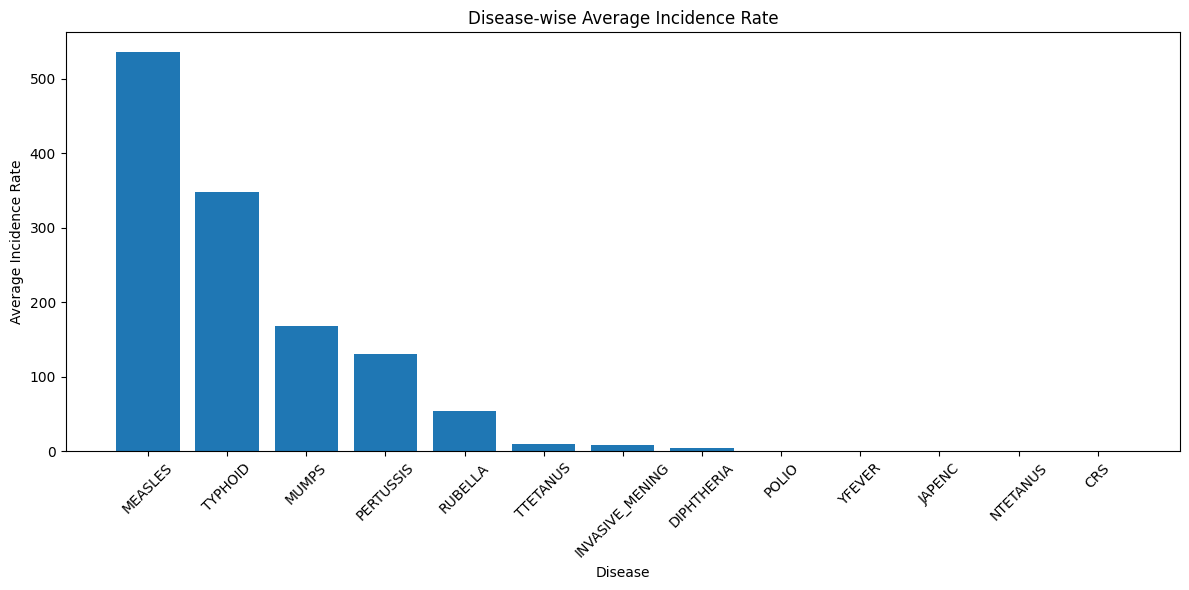

In [ ]:
# ==========================================
# DISEASE-WISE AVERAGE INCIDENCE RATE CHART
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    disease_incidence_clean["DISEASE"],
    disease_incidence_clean["Average_Incidence"]
)

plt.title("Disease-wise Average Incidence Rate")
plt.xlabel("Disease")
plt.ylabel("Average Incidence Rate")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# COVERAGE DATA - ANTIGEN CHECK
# ==========================================

print("===== COVERAGE ANTIGEN LIST =====")

coverage_antigens = (
    df["ANTIGEN"]
    .dropna()
    .unique()
)

print("Total unique antigens:", len(coverage_antigens))

for antigen in sorted(coverage_antigens):
    print(antigen)

===== COVERAGE ANTIGEN LIST =====
Total unique antigens: 69
15HPV1_F
15HPV1_M
15HPVC_F
15HPVC_M
BCG
DIPHCV4
DIPHCV5
DIPHCV6
DTPCV1
DTPCV3
FLU_ALL
FLU_CHILD1
FLU_CHILD2
FLU_CHRONIC_ADULT
FLU_CHRONIC_ALL
FLU_CHRONIC_PED
FLU_ELDERLY
FLU_HAJ
FLU_HCW
FLU_OTHER
FLU_PW
FLU_RESIDENT
HEPB3
HEPB_BD
HEPB_BDALL
HIB3
HPV_FEM
HPV_MALE
IPV1
IPV1_FRAC
IPV2
IPV2_FRAC
JAPENC
JAPENC_1
JAPENC_C
MALARIA1
MALARIA3
MALARIA4
MCV1
MCV2
MCV2X2
MENACYW_C
MENA_C
MENB_C
MEN_ACYW_CONJ
MEN_A_CONJ
MEN_B
PAB
PCV1
PCV2
PCV3
PERCV4
PERCV_PW
POL3
PRHPV1_F
PRHPV1_M
PRHPVC_F
PRHPVC_M
RCV1
ROTA1
ROTAC
TT2PLUS
TTCV4
TTCV5
TTCV6
TYPHOID
TYPHOID_CONJ
VAD1
YFV


In [ ]:
# ==========================================
# DISEASE - VACCINATION ANTIGEN MAPPING
# ==========================================

disease_antigen_mapping = {
    "MEASLES": [
        "MCV1",
        "MCV2",
        "MCV2X2"
    ],

    "RUBELLA": [
        "RCV1"
    ],

    "POLIO": [
        "POL3",
        "IPV1",
        "IPV2",
        "IPV1_FRAC",
        "IPV2_FRAC"
    ],

    "JAPENC": [
        "JAPENC",
        "JAPENC_1",
        "JAPENC_C"
    ],

    "TYPHOID": [
        "TYPHOID",
        "TYPHOID_CONJ"
    ],

    "YFEVER": [
        "YFV"
    ],

    "DIPHTHERIA": [
        "DIPHCV4",
        "DIPHCV5",
        "DIPHCV6",
        "DTPCV1",
        "DTPCV3"
    ],

    "PERTUSSIS": [
        "DTPCV1",
        "DTPCV3",
        "DIPHCV4",
        "DIPHCV5",
        "DIPHCV6"
    ],

    "TTETANUS": [
        "TT2PLUS",
        "TTCV4",
        "TTCV5",
        "TTCV6"
    ],

    "NTETANUS": [
        "TT2PLUS",
        "TTCV4",
        "TTCV5",
        "TTCV6"
    ],

    "INVASIVE_MENING": [
        "MENACYW_C",
        "MENA_C",
        "MENB_C",
        "MEN_ACYW_CONJ",
        "MEN_A_CONJ",
        "MEN_B"
    ]
}


print("===== DISEASE - ANTIGEN MAPPING =====")

for disease, antigens in disease_antigen_mapping.items():
    print("\n", disease)
    print("Antigens:", ", ".join(antigens))

print("\nTotal diseases mapped:",
      len(disease_antigen_mapping))

===== DISEASE - ANTIGEN MAPPING =====

 MEASLES
Antigens: MCV1, MCV2, MCV2X2

 RUBELLA
Antigens: RCV1

 POLIO
Antigens: POL3, IPV1, IPV2, IPV1_FRAC, IPV2_FRAC

 JAPENC
Antigens: JAPENC, JAPENC_1, JAPENC_C

 TYPHOID
Antigens: TYPHOID, TYPHOID_CONJ

 YFEVER
Antigens: YFV

 DIPHTHERIA
Antigens: DIPHCV4, DIPHCV5, DIPHCV6, DTPCV1, DTPCV3

 PERTUSSIS
Antigens: DTPCV1, DTPCV3, DIPHCV4, DIPHCV5, DIPHCV6

 TTETANUS
Antigens: TT2PLUS, TTCV4, TTCV5, TTCV6

 NTETANUS
Antigens: TT2PLUS, TTCV4, TTCV5, TTCV6

 INVASIVE_MENING
Antigens: MENACYW_C, MENA_C, MENB_C, MEN_ACYW_CONJ, MEN_A_CONJ, MEN_B

Total diseases mapped: 11


In [ ]:
# ==========================================
# CHECK MAPPED ANTIGENS IN COVERAGE DATA
# ==========================================

# All antigens from our mapping
mapped_antigens = []

for disease, antigens in disease_antigen_mapping.items():
    mapped_antigens.extend(antigens)

# Remove duplicates
mapped_antigens = sorted(set(mapped_antigens))

print("===== MAPPED ANTIGENS CHECK =====")

print("Total mapped unique antigens:",
      len(mapped_antigens))

print("\nMapped antigens:")
print(mapped_antigens)


# ------------------------------------------
# Coverage records for mapped antigens
# ------------------------------------------

mapped_coverage = df[
    df["ANTIGEN"].isin(mapped_antigens)
].copy()

print("\n===== COVERAGE RECORD CHECK =====")

print("Total coverage records for mapped antigens:",
      len(mapped_coverage))

print("Unique countries/regions:",
      mapped_coverage["CODE"].nunique())

print("Year range:",
      mapped_coverage["YEAR"].min(),
      "to",
      mapped_coverage["YEAR"].max())


# ------------------------------------------
# Antigen-wise record count
# ------------------------------------------

antigen_counts = (
    mapped_coverage
    .groupby("ANTIGEN")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Record_Count")
)

print("\n===== ANTIGEN-WISE RECORD COUNT =====")

display(antigen_counts)


# ------------------------------------------
# Missing coverage by antigen
# ------------------------------------------

missing_coverage = (
    mapped_coverage
    .groupby("ANTIGEN")["COVERAGE"]
    .apply(lambda x: x.isnull().sum())
    .reset_index(name="Missing_Coverage")
)

print("\n===== MISSING COVERAGE BY ANTIGEN =====")

display(missing_coverage)

===== MAPPED ANTIGENS CHECK =====
Total mapped unique antigens: 30

Mapped antigens:
['DIPHCV4', 'DIPHCV5', 'DIPHCV6', 'DTPCV1', 'DTPCV3', 'IPV1', 'IPV1_FRAC', 'IPV2', 'IPV2_FRAC', 'JAPENC', 'JAPENC_1', 'JAPENC_C', 'MCV1', 'MCV2', 'MCV2X2', 'MENACYW_C', 'MENA_C', 'MENB_C', 'MEN_ACYW_CONJ', 'MEN_A_CONJ', 'MEN_B', 'POL3', 'RCV1', 'TT2PLUS', 'TTCV4', 'TTCV5', 'TTCV6', 'TYPHOID', 'TYPHOID_CONJ', 'YFV']

===== COVERAGE RECORD CHECK =====
Total coverage records for mapped antigens: 205254
Unique countries/regions: 245
Year range: 1980 to 2023

===== ANTIGEN-WISE RECORD COUNT =====


,ANTIGEN,Record_Count
0,DTPCV3,26015
1,POL3,26005
2,MCV1,25939
3,DTPCV1,19760
4,MCV2,19317
5,RCV1,17356
6,TT2PLUS,14684
7,YFV,14640
8,JAPENC,6477
9,IPV1,6114



===== MISSING COVERAGE BY ANTIGEN =====


,ANTIGEN,Missing_Coverage
0,DIPHCV4,914
1,DIPHCV5,1224
2,DIPHCV6,1758
3,DTPCV1,1922
4,DTPCV3,1345
5,IPV1,1221
6,IPV1_FRAC,2292
7,IPV2,611
8,IPV2_FRAC,2306
9,JAPENC,6076


In [ ]:
# ==========================================
# MEASLES COVERAGE vs MEASLES INCIDENCE
# ==========================================

# ------------------------------------------
# 1. Select Measles vaccination coverage
# ------------------------------------------

measles_coverage = df[
    df["ANTIGEN"].isin(["MCV1", "MCV2", "MCV2X2"])
].copy()

measles_coverage = measles_coverage[
    [
        "CODE",
        "NAME",
        "YEAR",
        "ANTIGEN",
        "COVERAGE"
    ]
]


# ------------------------------------------
# 2. Remove missing coverage
# ------------------------------------------

measles_coverage = measles_coverage.dropna(
    subset=["COVERAGE"]
).copy()


# ------------------------------------------
# 3. Keep reasonable coverage values
# ------------------------------------------
# Values above 100 are retained separately in
# original data, but not used in this basic
# percentage comparison.

measles_coverage_valid = measles_coverage[
    (measles_coverage["COVERAGE"] >= 0) &
    (measles_coverage["COVERAGE"] <= 100)
].copy()


# ------------------------------------------
# 4. Prepare Measles incidence
# ------------------------------------------

measles_incidence = incidence_clean[
    incidence_clean["DISEASE"] == "MEASLES"
].copy()

measles_incidence = measles_incidence[
    [
        "CODE",
        "NAME",
        "YEAR",
        "INCIDENCE_RATE"
    ]
]


# ------------------------------------------
# 5. Merge by Country Code + Year
# ------------------------------------------

measles_analysis = pd.merge(
    measles_coverage_valid,
    measles_incidence,
    on=["CODE", "YEAR"],
    how="inner"
)


# ------------------------------------------
# 6. Display result
# ------------------------------------------

print("===== MEASLES COVERAGE VS INCIDENCE =====")

print("Total analysis records:",
      len(measles_analysis))

print("Unique countries/regions:",
      measles_analysis["CODE"].nunique())

print("Year range:",
      measles_analysis["YEAR"].min(),
      "to",
      measles_analysis["YEAR"].max())

print("\nMissing values:")

display(
    measles_analysis[
        ["COVERAGE", "INCIDENCE_RATE"]
    ].isnull().sum()
)


# ------------------------------------------
# 7. First 20 records

===== MEASLES COVERAGE VS INCIDENCE =====
Total analysis records: 30066
Unique countries/regions: 221
Year range: 1980 to 2023

Missing values:


,0
COVERAGE,0
INCIDENCE_RATE,0


In [ ]:
# ==========================================
# MEASLES COVERAGE VS INCIDENCE
# CORRELATION ANALYSIS
# ==========================================

print("===== MEASLES COVERAGE VS INCIDENCE =====")

# Correlation
correlation = measles_analysis[
    ["COVERAGE", "INCIDENCE_RATE"]
].corr()

print("\nCorrelation Matrix:")

display(correlation)


# Extract correlation value
correlation_value = correlation.loc[
    "COVERAGE",
    "INCIDENCE_RATE"
]

print("\nCorrelation between vaccination coverage",
      "and measles incidence:",
      round(correlation_value, 4))


# ------------------------------------------
# Basic statistics
# ------------------------------------------

print("\n===== BASIC STATISTICS =====")

print("Average vaccination coverage:",
      round(measles_analysis["COVERAGE"].mean(), 2))

print("Average measles incidence:",
      round(measles_analysis["INCIDENCE_RATE"].mean(), 2))

print("Median vaccination coverage:",
      round(measles_analysis["COVERAGE"].median(), 2))

print("Median measles incidence:",
      round(measles_analysis["INCIDENCE_RATE"].median(), 2))

===== MEASLES COVERAGE VS INCIDENCE =====

Correlation Matrix:


,COVERAGE,INCIDENCE_RATE
COVERAGE,1.000000,-0.170257
INCIDENCE_RATE,-0.170257,1.000000



Correlation between vaccination coverage and measles incidence: -0.1703

===== BASIC STATISTICS =====
Average vaccination coverage: 79.61
Average measles incidence: 332.37
Median vaccination coverage: 88.0
Median measles incidence: 6.0


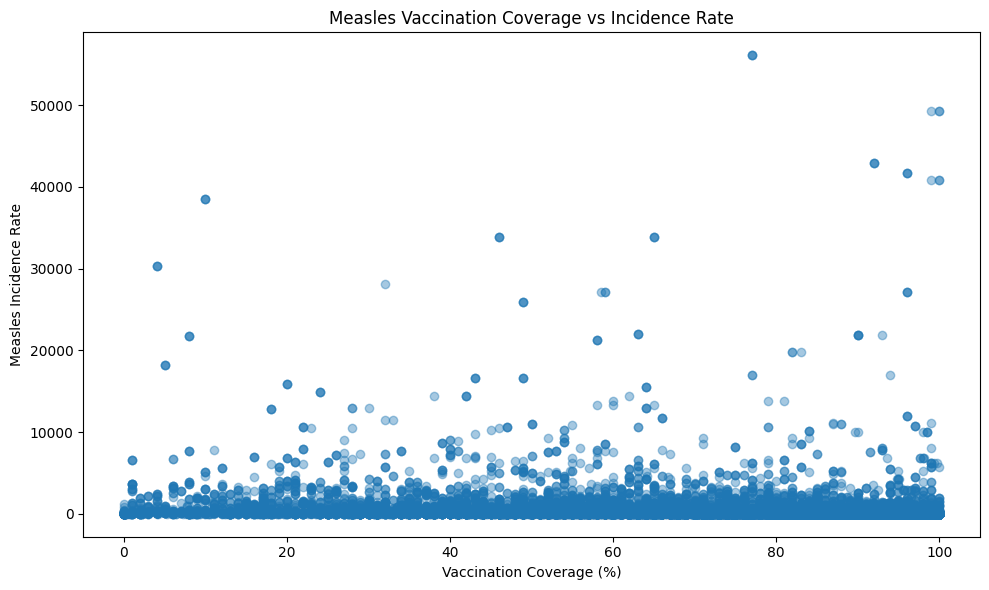

In [ ]:
# ==========================================
# SCATTER PLOT
# VACCINATION COVERAGE VS MEASLES INCIDENCE
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    measles_analysis["COVERAGE"],
    measles_analysis["INCIDENCE_RATE"],
    alpha=0.4
)

plt.title("Measles Vaccination Coverage vs Incidence Rate")
plt.xlabel("Vaccination Coverage (%)")
plt.ylabel("Measles Incidence Rate")

plt.tight_layout()
plt.show()

===== FINAL MEASLES ANALYSIS =====

Measles vaccination records: 34186
Country-year vaccination records: 9749
Measles incidence records: 8419

Final country-year analysis records: 8023
Unique countries/regions: 221
Year range: 1980 to 2023

===== PEARSON CORRELATION =====
Correlation between vaccination coverage and measles incidence: -0.1994

===== SPEARMAN CORRELATION =====
Spearman correlation: -0.4455

===== BASIC STATISTICS =====
Average vaccination coverage: 77.03
Median vaccination coverage: 84.0
Average measles incidence: 440.03
Median measles incidence: 14.2


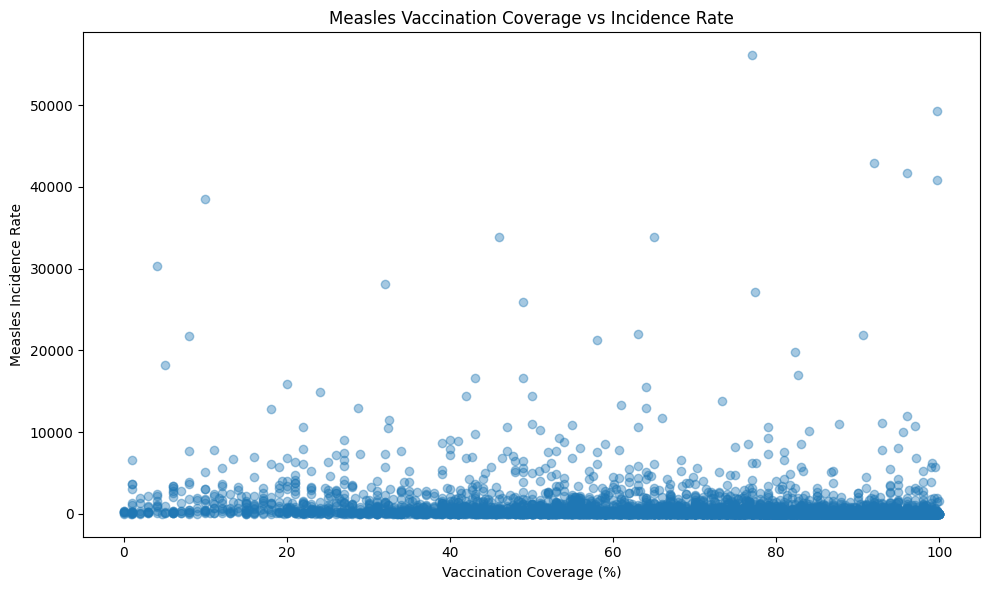


===== SAMPLE FINAL DATA =====


,CODE,NAME,YEAR,COVERAGE,INCIDENCE_RATE
0,ABW,Aruba,2017,93.000000,0.0
1,ABW,Aruba,2018,90.000000,0.0
2,ABW,Aruba,2019,90.000000,9.3
3,ABW,Aruba,2021,85.155000,0.0
4,ABW,Aruba,2022,87.305000,0.0
5,AFG,Afghanistan,1980,11.000000,2464.4
6,AFG,Afghanistan,1981,6.000000,2605.8
7,AFG,Afghanistan,1982,8.000000,1848.7
8,AFG,Afghanistan,1983,9.000000,1722.7
9,AFG,Afghanistan,1984,13.333333,1447.6


In [ ]:
# ============================================================
# FINAL MEASLES COVERAGE VS INCIDENCE ANALYSIS
# COUNTRY-YEAR LEVEL
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("===== FINAL MEASLES ANALYSIS =====")

# ------------------------------------------------------------
# 1. Select Measles vaccination coverage
# ------------------------------------------------------------

measles_coverage = df[
    df["ANTIGEN"].isin(["MCV1", "MCV2", "MCV2X2"])
].copy()

# Keep required columns
measles_coverage = measles_coverage[
    ["CODE", "NAME", "YEAR", "ANTIGEN", "COVERAGE"]
].copy()

# Remove missing coverage
measles_coverage = measles_coverage.dropna(
    subset=["COVERAGE"]
).copy()

# Keep only valid coverage values 0–100
measles_coverage_valid = measles_coverage[
    (measles_coverage["COVERAGE"] >= 0) &
    (measles_coverage["COVERAGE"] <= 100)
].copy()

print("\nMeasles vaccination records:", len(measles_coverage_valid))


# ------------------------------------------------------------
# 2. Aggregate vaccination coverage
#    One country + one year = one observation
# ------------------------------------------------------------

measles_coverage_country_year = (
    measles_coverage_valid
    .groupby(["CODE", "NAME", "YEAR"], as_index=False)["COVERAGE"]
    .mean()
)

print(
    "Country-year vaccination records:",
    len(measles_coverage_country_year)
)


# ------------------------------------------------------------
# 3. Select Measles incidence
# ------------------------------------------------------------

measles_incidence = incidence_clean[
    incidence_clean["DISEASE"] == "MEASLES"
].copy()

measles_incidence = measles_incidence[
    ["CODE", "NAME", "YEAR", "INCIDENCE_RATE"]
].copy()

print(
    "Measles incidence records:",
    len(measles_incidence)
)


# ------------------------------------------------------------
# 4. Merge vaccination coverage and incidence
# ------------------------------------------------------------

measles_final = pd.merge(
    measles_coverage_country_year,
    measles_incidence,
    on=["CODE", "NAME", "YEAR"],
    how="inner"
)

print(
    "\nFinal country-year analysis records:",
    len(measles_final)
)

print(
    "Unique countries/regions:",
    measles_final["CODE"].nunique()
)

print(
    "Year range:",
    measles_final["YEAR"].min(),
    "to",
    measles_final["YEAR"].max()
)


# ------------------------------------------------------------
# 5. Pearson Correlation
# ------------------------------------------------------------

pearson_corr = measles_final[
    ["COVERAGE", "INCIDENCE_RATE"]
].corr().loc[
    "COVERAGE",
    "INCIDENCE_RATE"
]

print("\n===== PEARSON CORRELATION =====")

print(
    "Correlation between vaccination coverage",
    "and measles incidence:",
    round(pearson_corr, 4)
)


# ------------------------------------------------------------
# 6. Spearman Correlation
# ------------------------------------------------------------

spearman_corr = measles_final[
    ["COVERAGE", "INCIDENCE_RATE"]
].corr(
    method="spearman"
).loc[
    "COVERAGE",
    "INCIDENCE_RATE"
]

print("\n===== SPEARMAN CORRELATION =====")

print(
    "Spearman correlation:",
    round(spearman_corr, 4)
)


# ------------------------------------------------------------
# 7. Basic Statistics
# ------------------------------------------------------------

print("\n===== BASIC STATISTICS =====")

print(
    "Average vaccination coverage:",
    round(measles_final["COVERAGE"].mean(), 2)
)

print(
    "Median vaccination coverage:",
    round(measles_final["COVERAGE"].median(), 2)
)

print(
    "Average measles incidence:",
    round(measles_final["INCIDENCE_RATE"].mean(), 2)
)

print(
    "Median measles incidence:",
    round(measles_final["INCIDENCE_RATE"].median(), 2)
)


# ------------------------------------------------------------
# 8. Scatter Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    measles_final["COVERAGE"],
    measles_final["INCIDENCE_RATE"],
    alpha=0.4
)

plt.title(
    "Measles Vaccination Coverage vs Incidence Rate"
)

plt.xlabel("Vaccination Coverage (%)")

plt.ylabel("Measles Incidence Rate")

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 9. Display first 10 records
# ------------------------------------------------------------

print("\n===== SAMPLE FINAL DATA =====")

display(
    measles_final.head(10)
)

In [ ]:
# ============================================================
# VACCINATION COVERAGE VS DISEASE INCIDENCE
# ALL MAPPED DISEASES
# ============================================================

import pandas as pd
import numpy as np

print("====================================================")
print("VACCINATION COVERAGE VS DISEASE INCIDENCE ANALYSIS")
print("====================================================")


# ------------------------------------------------------------
# Disease -> Vaccine Antigen Mapping
# ------------------------------------------------------------

disease_antigen_mapping = {
    "MEASLES": ["MCV1", "MCV2", "MCV2X2"],
    "RUBELLA": ["RCV1"],
    "POLIO": ["POL3", "IPV1", "IPV2", "IPV1_FRAC", "IPV2_FRAC"],
    "JAPENC": ["JAPENC", "JAPENC_1", "JAPENC_C"],
    "TYPHOID": ["TYPHOID", "TYPHOID_CONJ"],
    "YFEVER": ["YFV"],
    "DIPHTHERIA": [
        "DIPHCV4", "DIPHCV5", "DIPHCV6",
        "DTPCV1", "DTPCV3"
    ],
    "PERTUSSIS": [
        "DTPCV1", "DTPCV3",
        "DIPHCV4", "DIPHCV5", "DIPHCV6"
    ],
    "TTETANUS": [
        "TT2PLUS", "TTCV4", "TTCV5", "TTCV6"
    ],
    "NTETANUS": [
        "TT2PLUS", "TTCV4", "TTCV5", "TTCV6"
    ],
    "INVASIVE_MENING": [
        "MENACYW_C", "MENA_C", "MENB_C",
        "MEN_ACYW_CONJ", "MEN_A_CONJ", "MEN_B"
    ]
}


# ------------------------------------------------------------
# Store results
# ------------------------------------------------------------

results = []

disease_analysis_data = {}


# ------------------------------------------------------------
# Analyze each disease
# ------------------------------------------------------------

for disease, antigens in disease_antigen_mapping.items():

    print("\n----------------------------------------------------")
    print("Analyzing:", disease)
    print("Antigens:", ", ".join(antigens))
    print("----------------------------------------------------")

    # -----------------------------
    # Vaccination coverage
    # -----------------------------

    coverage_data = df[
        df["ANTIGEN"].isin(antigens)
    ].copy()

    coverage_data = coverage_data[
        ["CODE", "NAME", "YEAR", "ANTIGEN", "COVERAGE"]
    ].copy()

    coverage_data = coverage_data.dropna(
        subset=["COVERAGE"]
    )

    # Keep valid coverage only
    coverage_data = coverage_data[
        (coverage_data["COVERAGE"] >= 0) &
        (coverage_data["COVERAGE"] <= 100)
    ]

    # One country-year = one coverage value
    coverage_country_year = (
        coverage_data
        .

_IncompleteInputError: incomplete input (2921882832.py, line 91)

In [ ]:
# ============================================================
# VACCINATION COVERAGE VS DISEASE INCIDENCE
# ALL MAPPED DISEASES
# ============================================================

import pandas as pd
import numpy as np

print("====================================================")
print("VACCINATION COVERAGE VS DISEASE INCIDENCE ANALYSIS")
print("====================================================")

# Disease and vaccine antigen mapping

disease_antigen_mapping = {
    "MEASLES": ["MCV1", "MCV2", "MCV2X2"],
    "RUBELLA": ["RCV1"],
    "POLIO": ["POL3", "IPV1", "IPV2", "IPV1_FRAC", "IPV2_FRAC"],
    "JAPENC": ["JAPENC", "JAPENC_1", "JAPENC_C"],
    "TYPHOID": ["TYPHOID", "TYPHOID_CONJ"],
    "YFEVER": ["YFV"],
    "DIPHTHERIA": [
        "DIPHCV4", "DIPHCV5", "DIPHCV6",
        "DTPCV1", "DTPCV3"
    ],
    "PERTUSSIS": [
        "DTPCV1", "DTPCV3",
        "DIPHCV4", "DIPHCV5", "DIPHCV6"
    ],
    "TTETANUS": [
        "TT2PLUS", "TTCV4", "TTCV5", "TTCV6"
    ],
    "NTETANUS": [
        "TT2PLUS", "TTCV4", "TTCV5", "TTCV6"
    ],
    "INVASIVE_MENING": [
        "MENACYW_C", "MENA_C", "MENB_C",
        "MEN_ACYW_CONJ", "MEN_A_CONJ", "MEN_B"
    ]
}

# Store results
results = []

# Store detailed analysis for each disease
disease_analysis_data = {}

# ------------------------------------------------------------
# Disease-wise analysis
# ------------------------------------------------------------

for disease, antigens in disease_antigen_mapping.items():

    print("\n----------------------------------------------")
    print("Analyzing:", disease)
    print("----------------------------------------------")

    # Vaccination coverage data
    coverage_data = df[
        df["ANTIGEN"].isin(antigens)
    ].copy()

    coverage_data = coverage_data[
        ["CODE", "NAME", "YEAR", "ANTIGEN", "COVERAGE"]
    ]

    # Remove missing coverage
    coverage_data = coverage_data.dropna(
        subset=["COVERAGE"]
    )

    # Keep valid coverage between 0 and 100
    coverage_data = coverage_data[
        (coverage_data["COVERAGE"] >= 0) &
        (coverage_data["COVERAGE"] <= 100)
    ]

    # Average multiple antigens at country-year level
    coverage_country_year = (
        coverage_data
        .groupby(
            ["CODE", "NAME", "YEAR"],
            as_index=False
        )["COVERAGE"]
        .mean()
    )

    # Disease incidence data
    incidence_data = incidence_clean[
        incidence_clean["DISEASE"] == disease
    ].copy()

    incidence_data = incidence_data[
        ["CODE", "NAME", "YEAR", "INCIDENCE_RATE"]
    ]

    # Merge coverage and incidence
    analysis_data = pd.merge(
        coverage_country_year,
        incidence_data,
        on=["CODE", "NAME", "YEAR"],
        how="inner"
    )

    # Save detailed data
    disease_analysis_data[disease] = analysis_data

    # Calculate correlations
    if len(analysis_data) >= 2:

        pearson = analysis_data[
            ["COVERAGE", "INCIDENCE_RATE"]
        ].corr(method="pearson").loc[
            "COVERAGE",
            "INCIDENCE_RATE"
        ]

        spearman = analysis_data[
            ["COVERAGE", "INCIDENCE_RATE"]
        ].corr(method="spearman").loc[
            "COVERAGE",
            "INCIDENCE_RATE"
        ]

    else:
        pearson = np.nan
        spearman = np.nan

    # Store summary
    results.append({
        "Disease": disease,
        "Records": len(analysis_data),
        "Countries": analysis_data["CODE"].nunique(),
        "Year_Start": (
            analysis_data["YEAR"].min()
            if len(analysis_data) > 0 else np.nan
        ),
        "Year_End": (
            analysis_data["YEAR"].max()
            if len(analysis_data) > 0 else np.nan
        ),
        "Avg_Coverage": (
            analysis_data["COVERAGE"].mean()
            if len(analysis

_IncompleteInputError: incomplete input (1741673839.py, line 144)

In [ ]:
results = []

for disease, antigens in disease_antigen_mapping.items():

    c = df[df["ANTIGEN"].isin(antigens)].copy()
    c = c[["CODE", "NAME", "YEAR", "COVERAGE"]]
    c = c.dropna(subset=["COVERAGE"])
    c = c[(c["COVERAGE"] >= 0) & (c["COVERAGE"] <= 100)]

    c = c.groupby(
        ["CODE", "NAME", "YEAR"],
        as_index=False
    )["COVERAGE"].mean()

    i = incidence_clean[
        incidence_clean["DISEASE"] == disease
    ][["CODE", "NAME", "YEAR", "INCIDENCE_RATE"]]

    a = pd.merge(
        c,
        i,
        on=["CODE", "NAME", "YEAR"],
        how="inner"
    )

    p = a["COVERAGE"].corr(a["INCIDENCE_RATE"])
    s = a["COVERAGE"].corr(
        a["INCIDENCE_RATE"],
        method="spearman"
    )

    results.append([
        disease,
        len(a),
        a["CODE"].nunique(),
        round(a["COVERAGE"].mean(), 2),
        round(a["INCIDENCE_RATE"].mean(), 2),
        round(p, 4),
        round(s, 4)
    ])

summary = pd.DataFrame(
    results,
    columns=[
        "Disease",
        "Records",
        "Countries",
        "Avg_Coverage",
        "Avg_Incidence",
        "Pearson",
        "Spearman"
    ]
)

display(summary)

,Disease,Records,Countries,Avg_Coverage,Avg_Incidence,Pearson,Spearman
0,MEASLES,8023,221,77.03,440.03,-0.1994,-0.4455
1,RUBELLA,3332,210,87.41,39.26,0.0044,-0.1116
2,POLIO,4359,219,86.52,0.88,-0.0054,-0.3479
3,JAPENC,216,46,56.36,1.43,0.0826,0.5665
4,TYPHOID,36,24,43.91,317.84,0.1770,0.1601
5,YFEVER,1086,99,56.34,0.84,0.0380,0.0031
6,DIPHTHERIA,7463,221,83.55,3.93,-0.0502,-0.3563
7,PERTUSSIS,7496,221,83.22,109.12,-0.2437,-0.2859
8,TTETANUS,3974,211,59.99,10.44,-0.1734,-0.3607
9,NTETANUS,4260,213,60.19,0.12,-0.0567,-0.3689


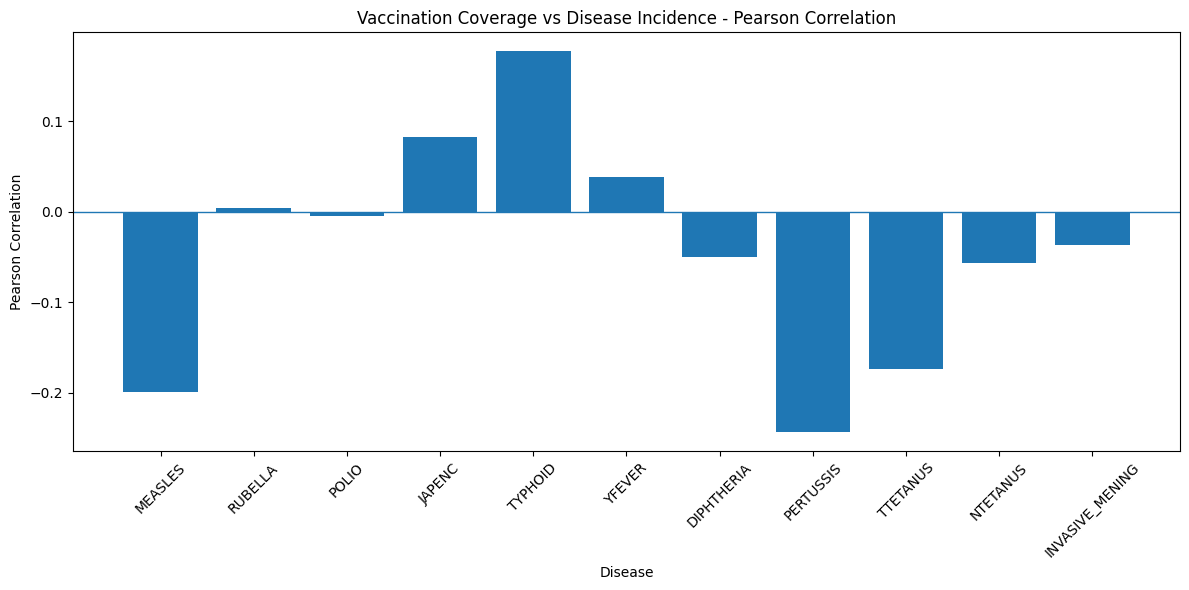

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    summary["Disease"],
    summary["Pearson"]
)

plt.axhline(0, linewidth=1)

plt.title("Vaccination Coverage vs Disease Incidence - Pearson Correlation")
plt.xlabel("Disease")
plt.ylabel("Pearson Correlation")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

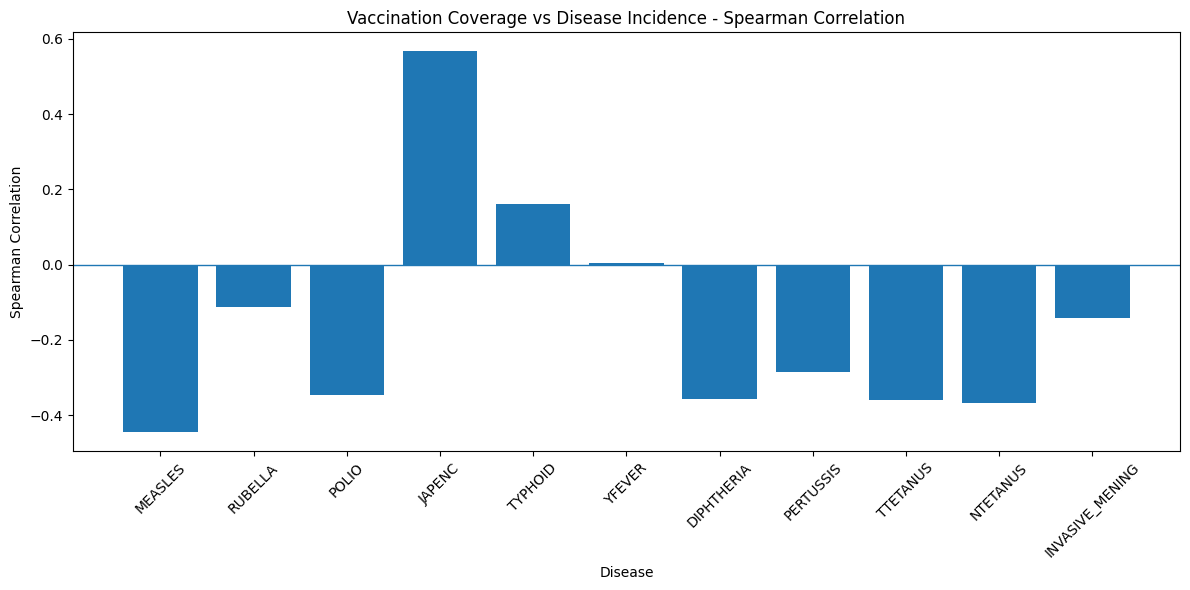

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    summary["Disease"],
    summary["Spearman"]
)

plt.axhline(0, linewidth=1)

plt.title(
    "Vaccination Coverage vs Disease Incidence - Spearman Correlation"
)

plt.xlabel("Disease")
plt.ylabel("Spearman Correlation")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FIRST DOSE VS SUBSEQUENT DOSE COVERAGE
# ============================================================

dose_comparison = df[
    df["ANTIGEN"].isin([
        "MCV1",
        "MCV2",
        "DTPCV1",
        "DTPCV3"
    ])
].copy()

dose_comparison = dose_comparison.dropna(
    subset=["COVERAGE"]
)

dose_comparison = dose_comparison[
    (dose_comparison["COVERAGE"] >= 0) &
    (dose_comparison["COVERAGE"] <= 100)
]

dose_summary = (
    dose_comparison
    .groupby("ANTIGEN")["COVERAGE"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

dose_summary["mean"] = dose_summary["mean"].round(2)
dose_summary["median"] = dose_summary["median"].round(2)

print("===== FIRST DOSE VS SUBSEQUENT DOSE =====")

display(dose_summary)

===== FIRST DOSE VS SUBSEQUENT DOSE =====


,ANTIGEN,count,mean,median
0,DTPCV1,17053,88.99,95.0
1,DTPCV3,24328,80.14,89.0
2,MCV1,23756,78.97,87.0
3,MCV2,9809,79.88,89.0


========== DOSE DROP-OFF ANALYSIS ==========

MCV1 -> MCV2
Records: 4304
Average MCV1 Coverage: 89.27 %
Average MCV2 Coverage: 76.83 %
Average Drop-off: 12.44 percentage points
Average Drop-off %: 15.32 %

DTPCV1 -> DTPCV3
Records: 9490
Average DTPCV1 Coverage: 87.62 %
Average DTPCV3 Coverage: 79.8 %
Average Drop-off: 7.83 percentage points
Average Drop-off %: 11.09 %


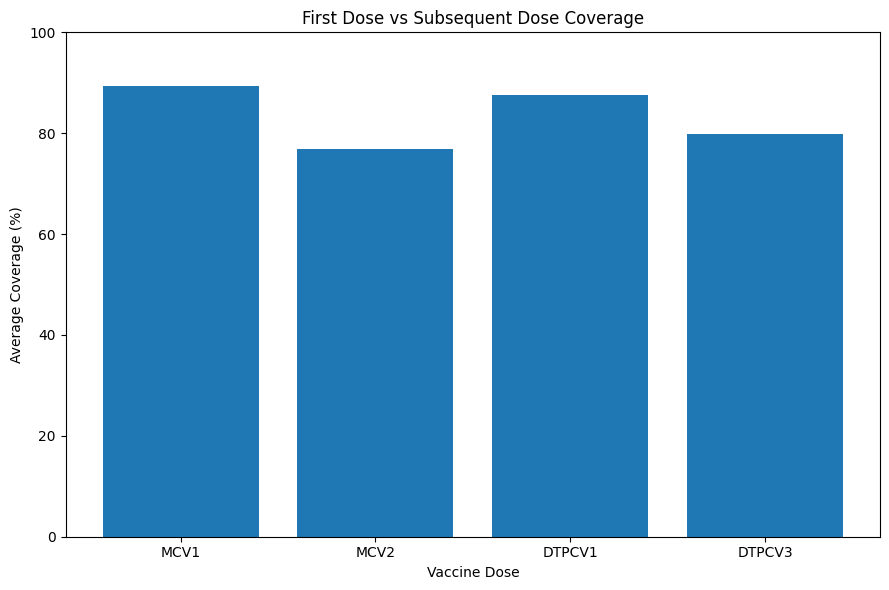

In [ ]:
# ============================================================
# ACTUAL DOSE DROP-OFF ANALYSIS
# MCV1 vs MCV2
# DTPCV1 vs DTPCV3
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Select required antigens
# ------------------------------------------------------------

dropoff_df = df[
    df["ANTIGEN"].isin(["MCV1", "MCV2", "DTPCV1", "DTPCV3"])
].copy()

# Keep only valid coverage values
dropoff_df = dropoff_df.dropna(subset=["COVERAGE"])

dropoff_df = dropoff_df[
    (dropoff_df["COVERAGE"] >= 0) &
    (dropoff_df["COVERAGE"] <= 100)
]

# ------------------------------------------------------------
# 2. Average duplicate records for same country-year-antigen
# ------------------------------------------------------------

dropoff_df = (
    dropoff_df
    .groupby(["CODE", "NAME", "YEAR", "ANTIGEN"])["COVERAGE"]
    .mean()
    .reset_index()
)

# ------------------------------------------------------------
# 3. Convert antigens into separate columns
# ------------------------------------------------------------

dropoff_pivot = dropoff_df.pivot_table(
    index=["CODE", "NAME", "YEAR"],
    columns="ANTIGEN",
    values="COVERAGE"
).reset_index()

# Remove column index name
dropoff_pivot.columns.name = None

# ------------------------------------------------------------
# 4. Calculate MCV1 -> MCV2 drop-off
# ------------------------------------------------------------

mcv = dropoff_pivot.dropna(
    subset=["MCV1", "MCV2"]
).copy()

mcv["MCV_Dropoff"] = mcv["MCV1"] - mcv["MCV2"]

mcv["MCV_Dropoff_Percent"] = (
    (mcv["MCV1"] - mcv["MCV2"])
    / mcv["MCV1"]
) * 100

# ------------------------------------------------------------
# 5. Calculate DTPCV1 -> DTPCV3 drop-off
# ------------------------------------------------------------

dtp = dropoff_pivot.dropna(
    subset=["DTPCV1", "DTPCV3"]
).copy()

dtp["DTPCV_Dropoff"] = dtp["DTPCV1"] - dtp["DTPCV3"]

dtp["DTPCV_Dropoff_Percent"] = (
    (dtp["DTPCV1"] - dtp["DTPCV3"])
    / dtp["DTPCV1"]
) * 100

# ------------------------------------------------------------
# 6. Summary
# ------------------------------------------------------------

print("========== DOSE DROP-OFF ANALYSIS ==========")

print("\nMCV1 -> MCV2")
print("Records:", len(mcv))
print("Average MCV1 Coverage:", round(mcv["MCV1"].mean(), 2), "%")
print("Average MCV2 Coverage:", round(mcv["MCV2"].mean(), 2), "%")
print("Average Drop-off:", round(mcv["MCV_Dropoff"].mean(), 2), "percentage points")
print(
    "Average Drop-off %:",
    round(mcv["MCV_Dropoff_Percent"].mean(), 2),
    "%"
)

print("\nDTPCV1 -> DTPCV3")
print("Records:", len(dtp))
print("Average DTPCV1 Coverage:", round(dtp["DTPCV1"].mean(), 2), "%")
print("Average DTPCV3 Coverage:", round(dtp["DTPCV3"].mean(), 2), "%")
print(
    "Average Drop-off:",
    round(dtp["DTPCV_Dropoff"].mean(), 2),
    "percentage points"
)
print(
    "Average Drop-off %:",
    round(dtp["DTPCV_Dropoff_Percent"].mean(), 2),
    "%"
)

# ------------------------------------------------------------
# 7. Create comparison data for graph
# ------------------------------------------------------------

graph_data = pd.DataFrame({
    "Dose": ["MCV1", "MCV2", "DTPCV1", "DTPCV3"],
    "Coverage": [
        mcv["MCV1"].mean(),
        mcv["MCV2"].mean(),
        dtp["DTPCV1"].mean(),
        dtp["DTPCV3"].mean()
    ]
})

# ------------------------------------------------------------
# 8. Bar chart
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.bar(
    graph_data["Dose"],
    graph_data["Coverage"]
)

plt.title("First Dose vs Subsequent Dose Coverage")
plt.xlabel("Vaccine Dose")
plt.ylabel("Average Coverage (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# VACCINE INTRODUCTION VS DISEASE CASES
# STEP 1: CHECK INTRODUCTION DATA
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Load Vaccine Introduction data
# ------------------------------------------------------------

intro_df = pd.read_excel(
    "/content/drive/MyDrive/Vaccination_Project/Dataset/cleaned_vaccine-introduction-data.xlsx"
)

print("===== VACCINE INTRODUCTION DATA =====")
print("Shape:", intro_df.shape)

print("\nColumns:")
print(intro_df.columns.tolist())

# ------------------------------------------------------------
# 2. Show first 10 records
# ------------------------------------------------------------

print("\n===== FIRST 10 RECORDS =====")

display(intro_df.head(10))

# ------------------------------------------------------------
# 3. Check missing values
# ------------------------------------------------------------

print("\n===== MISSING VALUES =====")

print(intro_df.isnull().sum())

# ------------------------------------------------------------
# 4. Check Intro column values
# ------------------------------------------------------------

print("\n===== INTRO COLUMN VALUES =====")

print(
    intro_df["Intro"]
    .value_counts(dropna=False)
    .head(20)
)

# ------------------------------------------------------------
# 5. Check vaccine descriptions
# ------------------------------------------------------------

print("\n===== UNIQUE VACCINE DESCRIPTIONS =====")

print(
    intro_df["Description"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .tolist()
)

# ------------------------------------------------------------
# 6. Load Reported Cases data
# ------------------------------------------------------------

cases_df = pd.read_excel(
    "/content/drive/MyDrive/Vaccination_Project/Dataset/cleaned_reported-cases-data.xlsx"
)

print("\n===== REPORTED CASES DATA =====")

print("Shape:", cases_df.shape)

print("\nColumns:")
print(cases_df.columns.tolist())

# ------------------------------------------------------------
# 7. Disease list
# ------------------------------------------------------------

print("\n===== DISEASES IN REPORTED CASES =====")

print(
    cases_df["DISEASE"]
    .dropna()
    .unique()
)

# ------------------------------------------------------------
# 8. Measles-related vaccine descriptions
# ------------------------------------------------------------

print("\n===== MEASLES-RELATED VACCINE DESCRIPTIONS =====")

measles_intro = intro_df[
    intro_df["Description"]
    .astype(str)
    .str.contains(
        "measles|MCV|MMR",
        case=False,
        na=False
    )
]

display(
    measles_intro[
        [
            "ISO_3_Code",
            "Country Name",
            "WHO Region",
            "Year",
            "Description",
            "Intro"
        ]
    ].head(30)
)

print(
    "\nNumber of measles-related introduction records:",
    len(measles_intro)
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Vaccination_Project/Dataset/cleaned_vaccine-introduction-data.xlsx'

In [ ]:
import os

print("===== EXCEL FILES AVAILABLE IN COLAB =====")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".xlsx"):
            print(os.path.join(root, file))

===== EXCEL FILES AVAILABLE IN COLAB =====
/content/cleaned_coverage-data.xlsx
/content/cleaned_incidence-rate-data.xlsx
/content/drive/MyDrive/Divya_Daily_Workload_Task_1.xlsx


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'cleaned_vaccine-introduction-data.xlsx', 'cleaned_coverage-data.xlsx', 'cleaned_incidence-rate-data.xlsx', 'drive', 'sample_data']


In [ ]:
# ============================================================
# VACCINE INTRODUCTION DATA - LOAD AND CHECK
# ============================================================

import pandas as pd

# Load vaccine introduction data
intro_df = pd.read_excel(
    "/content/cleaned_vaccine-introduction-data.xlsx"
)

print("===== VACCINE INTRODUCTION DATA =====")
print("Shape:", intro_df.shape)

print("\n===== COLUMNS =====")
print(intro_df.columns.tolist())

print("\n===== FIRST 10 RECORDS =====")
display(intro_df.head(10))

print("\n===== MISSING VALUES =====")
display(intro_df.isnull().sum())

print("\n===== INTRO VALUES =====")
display(
    intro_df["Intro"]
    .value_counts(dropna=False)
)

print("\n===== VACCINE DESCRIPTIONS =====")
display(
    intro_df["Description"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .sort_values()
    .to_frame()
)

===== VACCINE INTRODUCTION DATA =====
Shape: (138320, 6)

===== COLUMNS =====
['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']

===== FIRST 10 RECORDS =====


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023,Hepatitis B vaccine,Yes
3,AFG,Afghanistan,EMRO,2023,HepB birth dose,Yes
4,AFG,Afghanistan,EMRO,2023,Hib (Haemophilus influenzae type B) vaccine,Yes
5,AFG,Afghanistan,EMRO,2023,HPV (Human Papilloma Virus) vaccine,No
6,AFG,Afghanistan,EMRO,2023,IPV (Inactivated polio vaccine),Yes
7,AFG,Afghanistan,EMRO,2023,IPV (Inactivated polio vaccine) 2nd dose,Yes
8,AFG,Afghanistan,EMRO,2023,Japanese Encephalitis,No
9,AFG,Afghanistan,EMRO,2023,Malaria vaccine,No



===== MISSING VALUES =====


,0
ISO_3_CODE,0
COUNTRYNAME,0
WHO_REGION,0
YEAR,0
DESCRIPTION,0
INTRO,0



===== INTRO VALUES =====


KeyError: 'Intro'

In [ ]:
print("===== INTRO VALUES =====")

display(
    intro_df["INTRO"].value_counts(dropna=False)
)

print("\n===== VACCINE DESCRIPTIONS =====")

display(
    intro_df["DESCRIPTION"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .sort_values()
    .to_frame()
)

===== INTRO VALUES =====


,count
INTRO,
No,97695
Yes,37844
Yes (R),1708
Yes (P),825
High risk area,118
Yes (A),67
ND,39
Yes (O),22
Yes (D),2



===== VACCINE DESCRIPTIONS =====


,DESCRIPTION
5,HPV (Human Papilloma Virus) vaccine
3,HepB birth dose
1,Hepatitis A vaccine
2,Hepatitis B vaccine
4,Hib (Haemophilus influenzae type B) vaccine
6,IPV (Inactivated polio vaccine)
7,IPV (Inactivated polio vaccine) 2nd dose
8,Japanese Encephalitis
9,Malaria vaccine
10,Measles-containing vaccine 2nd dose


In [ ]:
# ============================================================
# VACCINE INTRODUCTION VS MEASLES CASES
# STEP 2: PREPARE INTRODUCTION DATA
# ============================================================

# ------------------------------------------------------------
# 1. Select Measles-containing vaccine
# ------------------------------------------------------------

measles_intro = intro_df[
    intro_df["DESCRIPTION"]
    .astype(str)
    .str.contains(
        "Measles-containing vaccine",
        case=False,
        na=False
    )
].copy()

print("===== MEASLES VACCINE INTRODUCTION =====")
print("Records:", len(measles_intro))

display(
    measles_intro.head(20)
)

# ------------------------------------------------------------
# 2. Create introduction status
# ------------------------------------------------------------

measles_intro["INTRODUCED"] = (
    measles_intro["INTRO"]
    .astype(str)
    .str.startswith("Yes")
)

# ------------------------------------------------------------
# 3. Country-year introduction summary
# ------------------------------------------------------------

intro_summary = (
    measles_intro
    .groupby(["ISO_3_CODE", "COUNTRYNAME", "YEAR"])
    ["INTRODUCED"]
    .max()
    .reset_index()
)

print("\n===== INTRODUCTION SUMMARY =====")

display(
    intro_summary.head(20)
)

# ------------------------------------------------------------
# 4. Load reported cases
# ------------------------------------------------------------

cases_df = pd.read_excel(
    "/content/cleaned_reported-cases-data.xlsx"
)

print("\n===== REPORTED CASES =====")
print("Shape:", cases_df.shape)

# ------------------------------------------------------------
# 5. Filter Measles cases
# ------------------------------------------------------------

measles_cases = cases_df[
    cases_df["DISEASE"] == "MEASLES"
].copy()

print("\n===== MEASLES CASES =====")
print("Records:", len(measles_cases))

display(
    measles_cases.head(10)
)

# ------------------------------------------------------------
# 6. Check columns
# ------------------------------------------------------------

print("\nIntroduction columns:")
print(intro_summary.columns.tolist())

print("\nCases columns:")
print(measles_cases.columns.tolist())

===== MEASLES VACCINE INTRODUCTION =====
Records: 10943


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
10,AFG,Afghanistan,EMRO,2023,Measles-containing vaccine 2nd dose,Yes
31,AFG,Afghanistan,EMRO,2022,Measles-containing vaccine 2nd dose,Yes
52,AFG,Afghanistan,EMRO,2021,Measles-containing vaccine 2nd dose,Yes
73,AFG,Afghanistan,EMRO,2020,Measles-containing vaccine 2nd dose,Yes
94,AFG,Afghanistan,EMRO,2019,Measles-containing vaccine 2nd dose,Yes
114,AFG,Afghanistan,EMRO,2018,Measles-containing vaccine 2nd dose,Yes
134,AFG,Afghanistan,EMRO,2017,Measles-containing vaccine 2nd dose,Yes
154,AFG,Afghanistan,EMRO,2016,Measles-containing vaccine 2nd dose,Yes
174,AFG,Afghanistan,EMRO,2015,Measles-containing vaccine 2nd dose,Yes
194,AFG,Afghanistan,EMRO,2014,Measles-containing vaccine 2nd dose,Yes



===== INTRODUCTION SUMMARY =====


,ISO_3_CODE,COUNTRYNAME,YEAR,INTRODUCED
0,AFG,Afghanistan,1963,False
1,AFG,Afghanistan,1964,False
2,AFG,Afghanistan,1965,False
3,AFG,Afghanistan,1966,False
4,AFG,Afghanistan,1967,False
5,AFG,Afghanistan,1968,False
6,AFG,Afghanistan,1969,False
7,AFG,Afghanistan,1970,False
8,AFG,Afghanistan,1971,False
9,AFG,Afghanistan,1972,False


FileNotFoundError: [Errno 2] No such file or directory: '/content/cleaned_reported-cases-data.xlsx'

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'cleaned_reported-cases-data.xlsx', 'cleaned_vaccine-introduction-data.xlsx', 'cleaned_coverage-data.xlsx', 'cleaned_incidence-rate-data.xlsx', 'drive', 'sample_data']


In [ ]:
# ============================================================
# MEASLES VACCINE INTRODUCTION VS REPORTED CASES
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Load reported cases
# ------------------------------------------------------------

cases_df = pd.read_excel(
    "/content/cleaned_reported-cases-data.xlsx"
)

# ------------------------------------------------------------
# 2. Filter Measles cases
# ------------------------------------------------------------

measles_cases = cases_df[
    cases_df["DISEASE"] == "MEASLES"
].copy()

# Keep required columns
measles_cases = measles_cases[
    ["CODE", "NAME", "YEAR", "CASES"]
].copy()

# ------------------------------------------------------------
# 3. Prepare introduction data
# ------------------------------------------------------------

# We already created measles_intro earlier.
# Keep only required columns.

intro_data = measles_intro[
    ["ISO_3_CODE", "COUNTRYNAME", "YEAR", "INTRODUCED"]
].copy()

# Rename columns to match cases data
intro_data = intro_data.rename(
    columns={
        "ISO_3_CODE": "CODE",
        "COUNTRYNAME": "NAME"
    }
)

# ------------------------------------------------------------
# 4. Merge introduction and cases
# ------------------------------------------------------------

measles_analysis = pd.merge(
    intro_data,
    measles_cases,
    on=["CODE", "NAME", "YEAR"],
    how="inner"
)

# ------------------------------------------------------------
# 5. Display result
# ------------------------------------------------------------

print("===== MEASLES INTRODUCTION VS CASES =====")

print("Records:", len(measles_analysis))

print(
    "Countries/Regions:",
    measles_analysis["CODE"].nunique()
)

print(
    "Year range:",
    measles_analysis["YEAR"].min(),
    "to",
    measles_analysis["YEAR"].max()
)

display(
    measles_analysis.head(20)
)

# ------------------------------------------------------------
# 6. Compare cases by introduction status
# ------------------------------------------------------------

print("\n===== CASES BY INTRODUCTION STATUS =====")

case_summary = (
    measles_analysis
    .groupby("INTRODUCED")["CASES"]
    .agg(
        Records="count",
        Average_Cases="mean",
        Median_Cases="median",
        Total_Cases="sum"
    )
    .reset_index()
)

case_summary["Average_Cases"] = case_summary["Average_Cases"].round(2)
case_summary["Median_Cases"] = case_summary["Median_Cases"].round(2)

display(case_summary)

===== MEASLES INTRODUCTION VS CASES =====
Records: 8056
Countries/Regions: 194
Year range: 1980 to 2023


,CODE,NAME,YEAR,INTRODUCED,CASES
0,AFG,Afghanistan,2023,True,2792.0
1,AFG,Afghanistan,2022,True,5166.0
2,AFG,Afghanistan,2021,True,2900.0
3,AFG,Afghanistan,2020,True,640.0
4,AFG,Afghanistan,2019,True,353.0
5,AFG,Afghanistan,2018,True,2012.0
6,AFG,Afghanistan,2017,True,1511.0
7,AFG,Afghanistan,2016,True,638.0
8,AFG,Afghanistan,2015,True,1154.0
9,AFG,Afghanistan,2014,True,492.0



===== CASES BY INTRODUCTION STATUS =====


,INTRODUCED,Records,Average_Cases,Median_Cases,Total_Cases
0,False,3636,11048.35,998.5,40171785.0
1,True,3947,1922.06,15.0,7586365.0


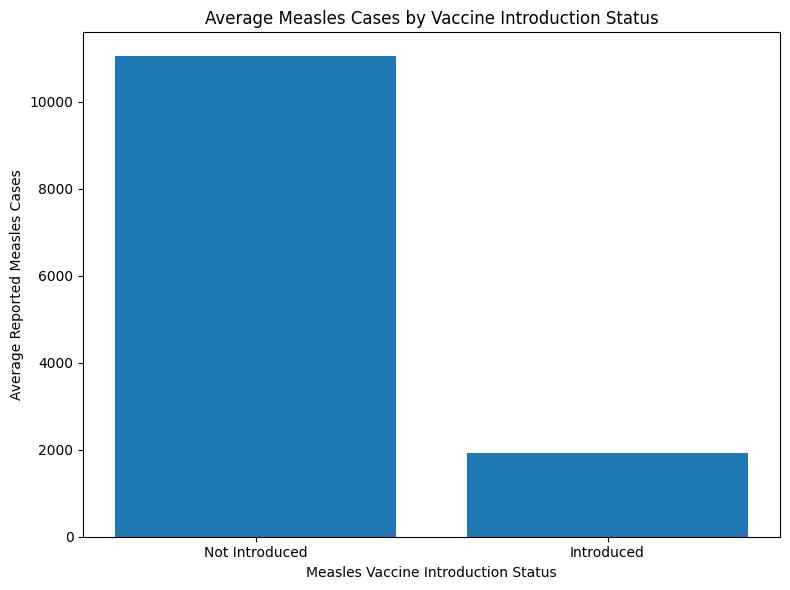

In [ ]:
import matplotlib.pyplot as plt

chart_data = case_summary.copy()

labels = ["Not Introduced", "Introduced"]

values = [
    chart_data.loc[
        chart_data["INTRODUCED"] == False,
        "Average_Cases"
    ].iloc[0],

    chart_data.loc[
        chart_data["INTRODUCED"] == True,
        "Average_Cases"
    ].iloc[0]
]

plt.figure(figsize=(8, 6))

plt.bar(labels, values)

plt.title(
    "Average Measles Cases by Vaccine Introduction Status"
)

plt.xlabel("Measles Vaccine Introduction Status")
plt.ylabel("Average Reported Measles Cases")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BOOSTER UPTAKE OVER TIME
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Select booster-related antigens
# ------------------------------------------------------------

booster_antigens = [
    "TT2PLUS",
    "TTCV4",
    "TTCV5",
    "TTCV6"
]

booster_df = df[
    df["ANTIGEN"].isin(booster_antigens)
].copy()

# ------------------------------------------------------------
# 2. Remove missing coverage
# ------------------------------------------------------------

booster_df = booster_df.dropna(
    subset=["COVERAGE"]
)

# Keep valid percentage values only
booster_df = booster_df[
    (booster_df["COVERAGE"] >= 0) &
    (booster_df["COVERAGE"] <= 100)
]

# ------------------------------------------------------------
# 3. Calculate year-wise average coverage
# ------------------------------------------------------------

booster_trend = (
    booster_df
    .groupby(["YEAR", "ANTIGEN"])["COVERAGE"]
    .mean()
    .reset_index()
)

# ------------------------------------------------------------
# 4. Round values
# ------------------------------------------------------------

booster_trend["COVERAGE"] = booster_trend["COVERAGE"].round(2)

print("===== BOOSTER UPTAKE OVER TIME =====")

display(
    booster_trend.head(20)
)

# ------------------------------------------------------------
# 5. Pivot for easier viewing
# ------------------------------------------------------------

booster_pivot = booster_trend.pivot(
    index="YEAR",
    columns="ANTIGEN",
    values="COVERAGE"
).reset_index()

print("\n===== YEAR-WISE BOOSTER COVERAGE =====")

display(
    booster_pivot.head(20)
)

# ------------------------------------------------------------
# 6. Overall statistics
# ------------------------------------------------------------

print("\n===== BOOSTER SUMMARY =====")

for antigen in booster_antigens:

    temp = booster_trend[
        booster_trend["ANTIGEN"] == antigen
    ]

    if len(temp) > 0:

        print(
            antigen,
            "Average Coverage:",
            round(temp["COVERAGE"].mean(), 2),
            "%"
        )

        print(
            "Highest Year:",
            int(
                temp.loc[
                    temp["COVERAGE"].idxmax(),
                    "YEAR"
                ]
            ),
            "| Coverage:",
            round(
                temp["COVERAGE"].max(),
                2
            ),
            "%"
        )

        print(
            "Lowest Year:",
            int(
                temp.loc[
                    temp["COVERAGE"].idxmin(),
                    "YEAR"
                ]
            ),
            "| Coverage:",
            round(
                temp["COVERAGE"].min(),
                2
            ),
            "%"
        )

        print()

# ------------------------------------------------------------
# 7. Line graph
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

for antigen in booster_antigens:

    temp = booster

===== BOOSTER UPTAKE OVER TIME =====


,YEAR,ANTIGEN,COVERAGE
0,1980,TT2PLUS,13.51
1,1981,TT2PLUS,15.46
2,1982,TT2PLUS,16.24
3,1983,TT2PLUS,17.75
4,1984,TT2PLUS,17.16
5,1985,TT2PLUS,21.79
6,1986,TT2PLUS,24.27
7,1987,TT2PLUS,32.31
8,1988,TT2PLUS,35.14
9,1989,TT2PLUS,38.71



===== YEAR-WISE BOOSTER COVERAGE =====


ANTIGEN,YEAR,TT2PLUS,TTCV4,TTCV5,TTCV6
0,1980,13.51,NaN,NaN,NaN
1,1981,15.46,NaN,NaN,NaN
2,1982,16.24,NaN,NaN,NaN
3,1983,17.75,NaN,NaN,NaN
4,1984,17.16,NaN,NaN,NaN
5,1985,21.79,NaN,NaN,NaN
6,1986,24.27,NaN,NaN,NaN
7,1987,32.31,NaN,NaN,NaN
8,1988,35.14,NaN,NaN,NaN
9,1989,38.71,NaN,NaN,NaN



===== BOOSTER SUMMARY =====
TT2PLUS Average Coverage: 52.01 %
Highest Year: 1997 | Coverage: 68.23 %
Lowest Year: 1980 | Coverage: 13.51 %

TTCV4 Average Coverage: 82.07 %
Highest Year: 2019 | Coverage: 83.55 %
Lowest Year: 2022 | Coverage: 80.74 %

TTCV5 Average Coverage: 78.02 %
Highest Year: 2018 | Coverage: 79.98 %
Lowest Year: 2021 | Coverage: 76.11 %

TTCV6 Average Coverage: 75.39 %
Highest Year: 2018 | Coverage: 78.3 %
Lowest Year: 2020 | Coverage: 71.01 %



NameError: name 'booster' is not defined

<Figure size 1200x600 with 0 Axes>

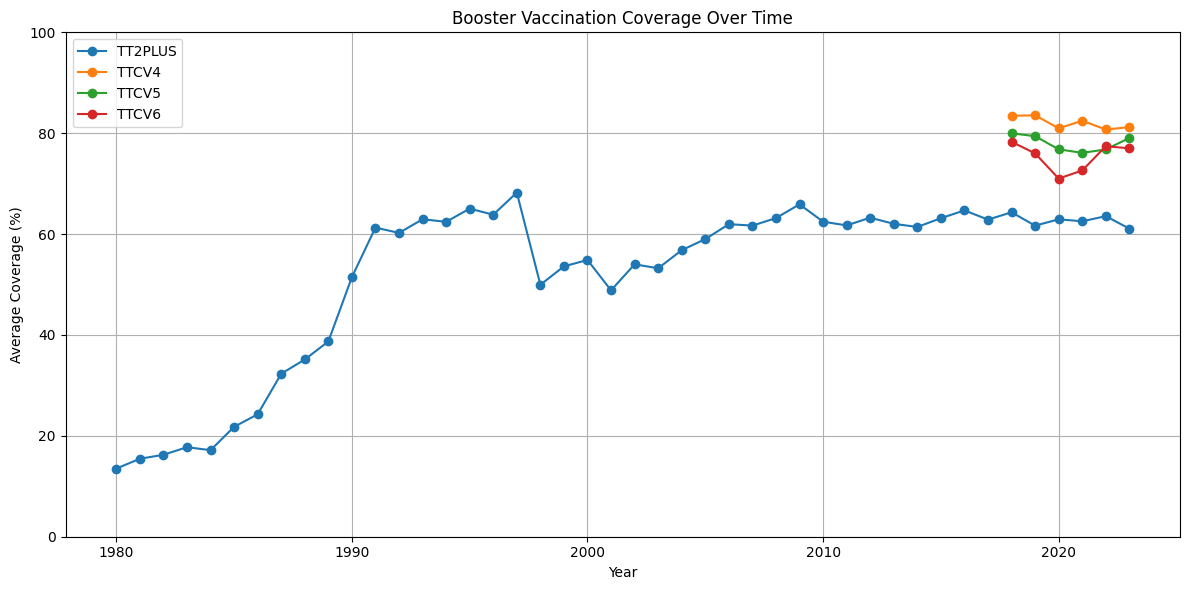

In [ ]:
# ============================================================
# BOOSTER UPTAKE OVER TIME - LINE GRAPH
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# TT2PLUS
temp = booster_trend[
    booster_trend["ANTIGEN"] == "TT2PLUS"
]

plt.plot(
    temp["YEAR"],
    temp["COVERAGE"],
    marker="o",
    label="TT2PLUS"
)

# TTCV4
temp = booster_trend[
    booster_trend["ANTIGEN"] == "TTCV4"
]

plt.plot(
    temp["YEAR"],
    temp["COVERAGE"],
    marker="o",
    label="TTCV4"
)

# TTCV5
temp = booster_trend[
    booster_trend["ANTIGEN"] == "TTCV5"
]

plt.plot(
    temp["YEAR"],
    temp["COVERAGE"],
    marker="o",
    label="TTCV5"
)

# TTCV6
temp = booster_trend[
    booster_trend["ANTIGEN"] == "TTCV6"
]

plt.plot(
    temp["YEAR"],
    temp["COVERAGE"],
    marker="o",
    label="TTCV6"
)

# Graph settings
plt.title("Booster Vaccination Coverage Over Time")

plt.xlabel("Year")

plt.ylabel("Average Coverage (%)")

plt.ylim(0, 100)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# HIGH VACCINATION COVERAGE BUT HIGH MEASLES INCIDENCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Check the available columns
# ------------------------------------------------------------

print("Columns available:")
print(measles_analysis.columns.tolist())


# ------------------------------------------------------------
# 2. Keep only valid vaccination coverage and incidence
# ------------------------------------------------------------

high_vaccination_data = measles_analysis[
    (measles_analysis["COVERAGE"] >= 90) &
    (measles_analysis["INCIDENCE_RATE"].notna()) &
    (measles_analysis["INCIDENCE_RATE"] > 0)
].copy()


# ------------------------------------------------------------
# 3. Find the 75th percentile of measles incidence
# ------------------------------------------------------------

incidence_75th = high_vaccination_data[
    "INCIDENCE_RATE"
].quantile(0.75)

print(
    "\n75th Percentile of Incidence:",
    round(incidence_75th, 2)
)


# ------------------------------------------------------------
# 4. Select high vaccination + high incidence records
# ------------------------------------------------------------

high_vacc_high_incidence = high_vaccination_data[
    high_vaccination_data["INCIDENCE_RATE"] >= incidence_75th
].copy()


# ------------------------------------------------------------
# 5. Sort by incidence
# ------------------------------------------------------------

high_vacc_high_incidence = (
    high_vacc_high_incidence
    .sort_values(
        by="INCIDENCE_RATE",
        ascending=False
    )
)


# ------------------------------------------------------------
# 6. Display top records
# ------------------------------------------------------------

print("\n===== HIGH VACCINATION + HIGH INCIDENCE =====")

display(
    high_vacc_high_incidence[
        [
            "CODE",
            "NAME",
            "YEAR",
            "COVERAGE",
            "INCIDENCE_RATE"
        ]
    ].head(20)
)


# ------------------------------------------------------------
# 7. Summary
# ------------------------------------------------------------

print("\n===== SUMMARY =====")

print(
    "Total high vaccination + high incidence records:",
    len(high_vacc_high_incidence)
)

print(
    "Countries/Regions:",
    high_vacc_high_incidence["CODE"].nunique()
)

print(
    "Average vaccination coverage:",
    round(
        high_vacc_high_incidence["COVERAGE"].mean(),
        2
    ),
    "%"
)

print(
    "Average measles incidence:",
    round(
        high_vacc_high_incidence["INCIDENCE_RATE"].mean(),
        2
    )
)

print(
    "Highest measles incidence:",
    round(
        high_vacc_high_incidence["INCIDENCE_RATE"].max(),
        2
    )
)


# ------------------------------------------------------------
# 8. Scatter plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    measles_analysis["COVERAGE"],
    measles_analysis["INCIDENCE_RATE"],
    alpha=0.3
)

plt.axvline(
    90,
    linestyle="--",
    label="90% Vaccination Coverage"
)

plt.xlabel("Measles Vaccination Coverage (%)")

plt.ylabel("Measles Incidence Rate")

plt.title(
    "High Vaccination Coverage vs Measles Incidence"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

Columns available:
['CODE', 'NAME', 'YEAR', 'INTRODUCED', 'CASES']


KeyError: 'COVERAGE'

In [ ]:
# ============================================================
# HIGH VACCINATION COVERAGE + HIGH MEASLES INCIDENCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Select measles vaccination antigens
# ------------------------------------------------------------

measles_antigens = ["MCV1", "MCV2", "MCV2X2"]

measles_coverage = df[
    df["ANTIGEN"].isin(measles_antigens)
].copy()


# ------------------------------------------------------------
# 2. Keep valid vaccination coverage values
# ------------------------------------------------------------

measles_coverage = measles_coverage.dropna(
    subset=["COVERAGE"]
)

measles_coverage = measles_coverage[
    (measles_coverage["COVERAGE"] >= 0) &
    (measles_coverage["COVERAGE"] <= 100)
]


# ------------------------------------------------------------
# 3. Calculate average measles vaccination coverage
#    for each country and year
# ------------------------------------------------------------

measles_coverage_yearly = (
    measles_coverage
    .groupby(["CODE", "NAME", "YEAR"])["COVERAGE"]
    .mean()
    .reset_index()
)


# ------------------------------------------------------------
# 4. Get measles incidence data
# ------------------------------------------------------------

measles_incidence = incidence_clean[
    incidence_clean["DISEASE"] == "MEASLES"
].copy()

measles_incidence = measles_incidence[
    ["

SyntaxError: unterminated string literal (detected at line 55) (136067328.py, line 55)

In [ ]:
# ============================================================
# HIGH VACCINATION COVERAGE + HIGH MEASLES INCIDENCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# 1. Measles vaccine antigens
measles_antigens = ["MCV1", "MCV2", "MCV2X2"]

measles_coverage = df[
    df["ANTIGEN"].isin(measles_antigens)
].copy()

# 2. Keep valid coverage values
measles_coverage = measles_coverage.dropna(
    subset=["COVERAGE"]
)

measles_coverage = measles_coverage[
    (measles_coverage["COVERAGE"] >= 0) &
    (measles_coverage["COVERAGE"] <= 100)
]

# 3. Country-year average vaccination coverage
measles_coverage_yearly = (
    measles_coverage
    .groupby(["CODE", "NAME", "YEAR"])["COVERAGE"]
    .mean()
    .reset_index()
)

# 4. Select measles incidence
measles_incidence = incidence_clean[
    incidence_clean["DISEASE"] == "MEASLES"
].copy()

measles_incidence = measles_incidence[
    ["CODE", "NAME", "YEAR", "INCIDENCE_RATE"]
]

# 5. Merge coverage + incidence
coverage_incidence = pd.merge(
    measles_coverage_yearly,
    measles_incidence,
    on=["CODE", "NAME", "YEAR"],
    how="inner"
)

# 6. Remove missing incidence
coverage_incidence = coverage_incidence.dropna(
    subset=["INCIDENCE_RATE"]
)

# Keep non-negative incidence
coverage_incidence = coverage_incidence[
    coverage_incidence["INCIDENCE_RATE"] >= 0
]

# 7. High vaccination coverage = 90% or more
high_vaccination = coverage_incidence[
    coverage_incidence["COVERAGE"] >= 90
].

SyntaxError: invalid syntax (1144739447.py, line 63)

In [ ]:
# HIGH VACCINATION + HIGH MEASLES INCIDENCE

# Measles vaccine coverage
m = df[df["ANTIGEN"].isin(["MCV1", "MCV2", "MCV2X2"])].copy()

# Valid coverage only
m = m.dropna(subset=["COVERAGE"])
m = m[(m["COVERAGE"] >= 0) & (m["COVERAGE"] <= 100)]

# Country-year average coverage
m = m.groupby(
    ["CODE", "NAME", "YEAR"],
    as_index=False
)["COVERAGE"].mean()

# Measles incidence
c = incidence_clean[
    incidence_clean["DISEASE"] == "MEASLES"
].copy()

c = c[
    ["CODE", "NAME", "YEAR", "INCIDENCE_RATE"]
]

# Merge
result = pd.merge(
    m,
    c,
    on=["CODE", "NAME", "YEAR"],
    how="inner"
)

# High vaccination coverage
result = result[result["COVERAGE"] >= 90].copy()

# Remove missing incidence
result = result.dropna(
    subset=["INCIDENCE_RATE"]
)

# High incidence threshold
threshold = result["INCIDENCE_RATE"].quantile(0.75)

# High vaccination + high incidence
high = result[
    result["INCIDENCE_RATE"] >= threshold
].copy()

# Sort
high = high.sort_values(
    "INCIDENCE_RATE",
    ascending=False
)

print("High vaccination coverage: 90% or more")
print("High incidence threshold:", round(threshold, 2))
print("Total records:", len(high))

print("\nTOP 20 RECORDS:")

print(
    high[
        ["CODE", "NAME", "YEAR", "COVERAGE", "INCIDENCE_RATE"]
    ].head(20).to_string(index=False)
)

print("\nAverage vaccination coverage:",
      round(high["COVERAGE"].mean(), 2), "%")

print("Average measles incidence:",
      round(high["INCIDENCE_RATE"].mean(), 2))

High vaccination coverage: 90% or more
High incidence threshold: 23.3
Total records: 744

TOP 20 RECORDS:
CODE                   NAME  YEAR  COVERAGE  INCIDENCE_RATE
 NIU                   Niue  1991 99.666667         49347.5
 SLB        Solomon Islands  1989 92.000000         42887.6
 ALB                Albania  1989 96.000000         41723.4
 COK           Cook Islands  1989 99.666667         40810.3
 MHL       Marshall Islands  2003 90.600000         21824.6
 MDV               Maldives  1995 96.000000         11961.9
 VGB British Virgin Islands  1989 93.000000         11067.2
 TON                  Tonga  1997 97.000000         10737.6
 MNG               Mongolia  2016 95.533333          9955.6
 MWI                 Malawi  2010 95.000000          8006.8
 SYC             Seychelles  1998 93.000000          7754.9
 MNG               Mongolia  2015 97.183333          6839.9
 TON                  Tonga  2019 99.166667          6236.4
 VGB British Virgin Islands  1990 99.000000          5

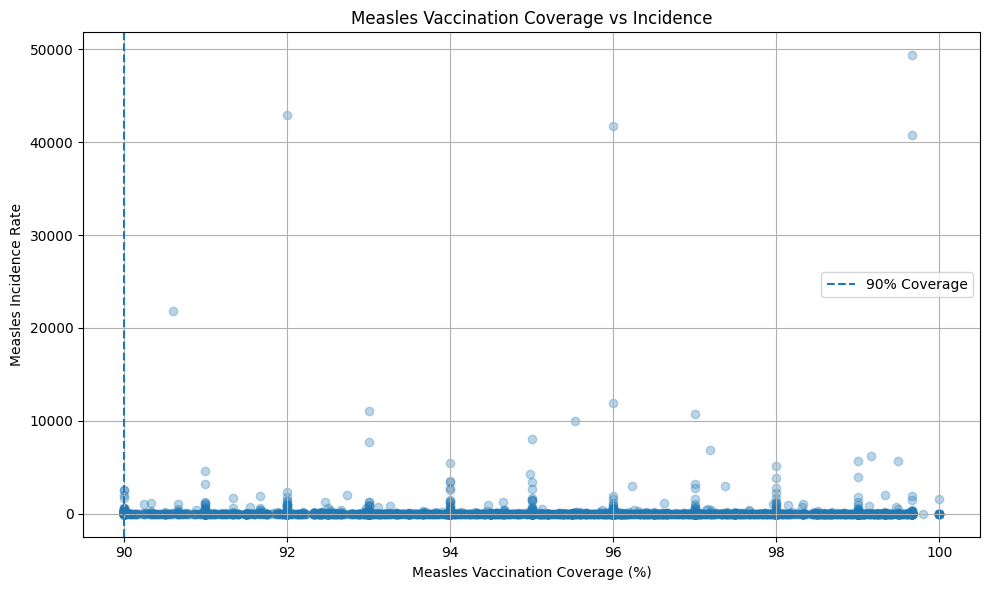

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    result["COVERAGE"],
    result["INCIDENCE_RATE"],
    alpha=0.3
)

plt.axvline(
    90,
    linestyle="--",
    label="90% Coverage"
)

plt.xlabel("Measles Vaccination Coverage (%)")
plt.ylabel("Measles Incidence Rate")
plt.title("Measles Vaccination Coverage vs Incidence")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

===== TOP 15 COUNTRIES/REGIONS BY AVERAGE MEASLES INCIDENCE =====


,CODE,NAME,Average_Incidence,Total_Records
105,KIR,Kiribati,3910.671053,38
138,MWI,Malawi,3839.144186,43
201,TUV,Tuvalu,3659.874194,31
142,NER,Niger,2618.370455,44
43,COK,Cook Islands,2592.634286,35
219,ZMB,Zambia,2542.939535,43
16,BDI,Burundi,2395.418605,43
213,WLF,Wallis and Futuna,2359.745000,20
151,OMN,Oman,2243.588372,43
173,SLB,Solomon Islands,2187.897297,37



===== SUMMARY =====
Total countries/regions: 221
Highest average incidence: 3910.67
Country/Region with highest average incidence: Kiribati
Average incidence: 3910.67


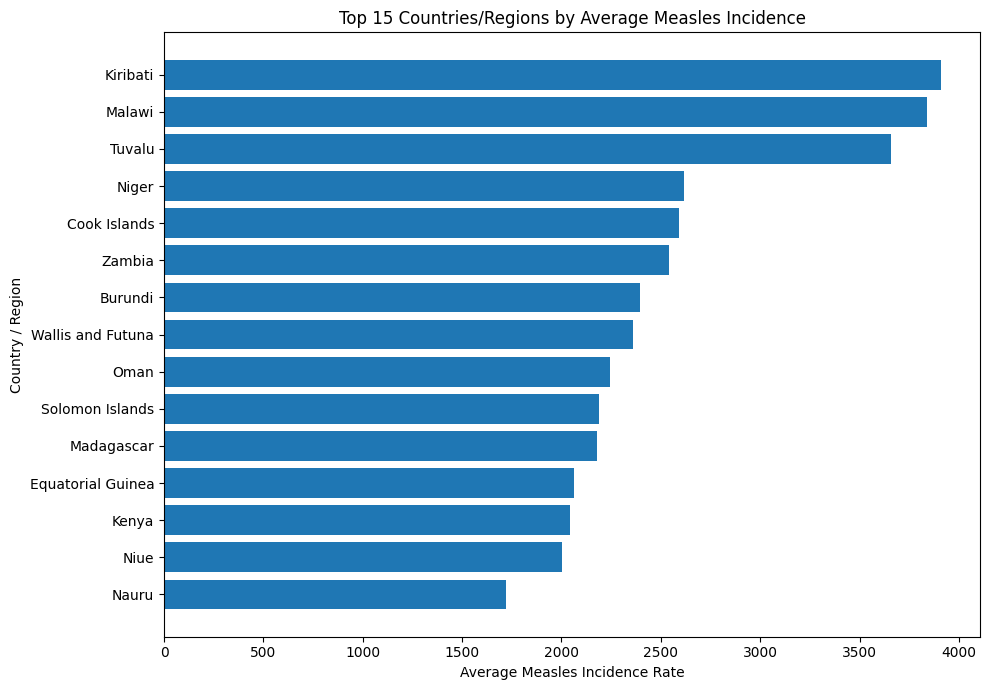

In [ ]:
# ============================================================
# GEOGRAPHIC DISEASE PREVALENCE - MEASLES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# 1. Select measles records
geo_measles = incidence_clean[
    incidence_clean["DISEASE"] == "MEASLES"
].copy()

# 2. Remove missing incidence values
geo_measles = geo_measles.dropna(
    subset=["INCIDENCE_RATE"]
)

# 3. Calculate average incidence by country/region
country_incidence = (
    geo_measles
    .groupby(["CODE", "NAME"])["INCIDENCE_RATE"]
    .agg(
        Average_Incidence="mean",
        Total_Records="count"
    )
    .reset_index()
)

# 4. Sort from highest to lowest
country_incidence = country_incidence.sort_values(
    "Average_Incidence",
    ascending=False
)

# 5. Display top 15 countries/regions
print("===== TOP 15 COUNTRIES/REGIONS BY AVERAGE MEASLES INCIDENCE =====")

display(
    country_incidence.head(15)
)

# 6. Summary
print("\n===== SUMMARY =====")

print(
    "Total countries/regions:",
    country_incidence["CODE"].nunique()
)

print(
    "Highest average incidence:",
    round(
        country_incidence["Average_Incidence"].max(),
        2
    )
)

top_country = country_incidence.iloc[0]

print(
    "Country/Region with highest average incidence:",
    top_country["NAME"]
)

print(
    "Average incidence:",
    round(
        top_country["Average_Incidence"],
        2
    )
)

# 7. Bar chart - Top 15
top15 = country_incidence.head(15).sort_values(
    "Average_Incidence"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top15["NAME"],
    top15["Average_Incidence"]
)

plt.xlabel("Average Measles Incidence Rate")

plt.ylabel("Country / Region")

plt.title(
    "Top 15 Countries/Regions by Average Measles Incidence"
)

plt.tight_layout()

plt.show()